
# HPA Classification
This notebook classifies HorizontalPodAutoscaler usage patterns across public GitHub repositories.


In [11]:

# ==== Setup, Enums, Logging, IO helpers ====
import os, sys, json, time, math, base64, hashlib
from pathlib import Path
from typing import Optional, List, Dict, Tuple
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import yaml
from yaml.loader import SafeLoader

# Directories
PROJ_DIR    = Path(".").resolve()
DATA_DIR    = PROJ_DIR / "data"
PARTIAL_DIR = DATA_DIR / "partial_results"
CACHE_DIR   = DATA_DIR / ".cache"
for d in [DATA_DIR, PARTIAL_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Logging
import logging
log = logging.getLogger("hpa_classify")
if not log.handlers:
    h = logging.StreamHandler(sys.stdout)
    h.setFormatter(logging.Formatter("%(asctime)s - hpa_classify - %(levelname)s - %(message)s"))
    log.addHandler(h)
log.setLevel(logging.INFO)

class Col:
    OWNER         = "Owner"
    PROJECT       = "Project"
    FILE_PATH     = "File Path"
    APIVERSION    = "apiVersion"
    IS_HELM       = "Is Helm Template"
    METRIC_TYPE   = "Metric Type"
    METRIC_NAME   = "Metric Name"
    TARGET_VALUE  = "Target Value"

class LogEvent:
    CACHE_HIT         = "CACHE_HIT"
    CACHE_MISS        = "CACHE_MISS"
    REQUEST_FAIL      = "REQUEST_FAIL"
    PARSE_YAML_FAIL   = "PARSE_YAML_FAIL"
    PERSIST           = "PERSIST"
    CLASSIFY          = "CLASSIFY"

# Pastel palette
def _pastel(n: int):
    import colorsys
    base = []
    for i in range(max(1, n)):
        hue = i / max(1, n)
        light = 0.78
        sat = 0.35
        r, g, b = colorsys.hls_to_rgb(hue, light, sat)
        base.append("#{0:02x}{1:02x}{2:02x}".format(int(r*255), int(g*255), int(b*255)))
    return base[:n]

def pastel_hist(ax, data, bins=30, title="", xlabel="", ylabel="frequency"):
    ax.hist(data, bins=bins, color=_pastel(1)[0])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, axis="y", alpha=0.2)

# Persistence helpers
from datetime import datetime
def _timestamp() -> str:
    return datetime.utcnow().strftime("%Y%m%d-%H%M%S")

def persist_df(df: pd.DataFrame, tag: str) -> Path:
    out = PARTIAL_DIR / f"{_timestamp()}-{tag}.csv"
    df.to_csv(out, index=False)
    log.info("%s %s -> %s", LogEvent.PERSIST, tag, out.resolve().as_posix())
    return out

def persist_df_both(df: pd.DataFrame, tag: str):
    ts = persist_df(df, tag)
    latest = DATA_DIR / f"{tag}_latest.csv"
    df.to_csv(latest, index=False)
    log.info("PERSIST latest alias for %s: %s", tag, latest.resolve().as_posix())
    return ts, latest

def latest_csv(tag: str) -> Optional[Path]:
    files = sorted(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    if files:
        return files[-1]
    alias = DATA_DIR / f"{tag}_latest.csv"
    return alias if alias.exists() else None

# Lightweight cache
def cache_key(path: str, params: Optional[dict]=None) -> Path:
    key = path
    if params:
        key += "?" + "&".join(f"{k}={params[k]}" for k in sorted(params))
    h = hashlib.sha1(key.encode()).hexdigest()
    return CACHE_DIR / f"{h}.json"

def cache_get(path: str, params: Optional[dict]=None) -> Optional[dict]:
    fp = cache_key(path, params)
    if fp.exists():
        try:
            return json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            return None
    return None

def cache_set(path: str, data: dict, params: Optional[dict]=None) -> None:
    fp = cache_key(path, params)
    fp.write_text(json.dumps(data), encoding="utf-8")

# GitHub client
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

class GitHubClient:
    def __init__(self, token: Optional[str] = None):
        self.session = requests.Session()
        retries = Retry(total=5, backoff_factor=0.5, status_forcelist=[429,500,502,503,504])
        self.session.mount("https://", HTTPAdapter(max_retries=retries))
        self.base = "https://api.github.com"
        self.headers = {
            "Accept": "application/vnd.github+json",
            "X-GitHub-Api-Version": "2022-11-28",
            "User-Agent": "hpa-classify-notebook"
        }
        if token:
            self.headers["Authorization"] = f"token {token}"

    def get(self, path: str, params: Optional[dict]=None) -> dict:
        url = self.base + path
        cached = cache_get(path, params)
        if cached is not None:
            return cached
        r = self.session.get(url, headers=self.headers, params=params, timeout=30)
        if r.status_code >= 300:
            log.warning("%s %s %s", LogEvent.REQUEST_FAIL, r.status_code, path)
            r.raise_for_status()
        data = r.json()
        cache_set(path, data, params)
        remain = int(r.headers.get("X-RateLimit-Remaining", "1"))
        reset  = int(r.headers.get("X-RateLimit-Reset", "0"))
        if remain <= 1 and reset:
            sleep_s = max(0, reset - int(time.time()) + 1)
            log.info("RATE_LIMIT_SLEEP %ss", sleep_s)
            time.sleep(sleep_s)
        return data

# Token via .env
try:
    from dotenv import load_dotenv
    _ = load_dotenv(PROJ_DIR / ".env")
except Exception:
    pass
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
gh = GitHubClient(GITHUB_TOKEN)

log.info("Environment ready. Data dir: %s", DATA_DIR.resolve().as_posix())


2025-10-08 11:06:46,640 - hpa_classify - INFO - Environment ready. Data dir: /home/calendario2009/Downloads/hpa_usage_refactored/data


In [12]:

# ==== Load phase artifacts ====
REQUIRED_P2 = ["repo_full_name", "stargazers_count", "created_at", "pushed_at"]
REQUIRED_P3 = ["Owner", "Project", "File Path", "apiVersion", "Is Helm Template", "raw_length"]
REQUIRED_P4 = ["Owner", "Project", "File Path", "Is Helm Template", "apiVersion",
               "Has Behavior", "MinReplicas", "MaxReplicas", "Metric Type", "Metric Name",
               "Target Kind", "Target Value"]

def read_csv_req(tag: str, required: list) -> pd.DataFrame:
    p = latest_csv(tag)
    if p is None or not p.exists() or p.stat().st_size == 0:
        log.info("No %s found. Returning empty DataFrame with required columns.", tag)
        return pd.DataFrame(columns=required)
    try:
        df = pd.read_csv(p)
    except pd.errors.EmptyDataError:
        df = pd.DataFrame(columns=required)
    # fill missing to keep pipeline running
    for c in required:
        if c not in df.columns:
            df[c] = np.nan
    return df

df_p2 = read_csv_req("phase2", REQUIRED_P2)
df_p3 = read_csv_req("phase3", REQUIRED_P3)
df_p4 = read_csv_req("phase4", REQUIRED_P4)

# Keys and dates
if not df_p3.empty:
    df_p3["repo_full_name"] = df_p3["Owner"].astype(str) + "/" + df_p3["Project"].astype(str)
if not df_p4.empty:
    df_p4["repo_full_name"] = df_p4["Owner"].astype(str) + "/" + df_p4["Project"].astype(str)

for c in ["created_at","pushed_at"]:
    if c in df_p2.columns:
        df_p2[c] = pd.to_datetime(df_p2[c], errors="coerce", utc=True)

log.info("Loaded artifacts, p2=%d, p3=%d, p4=%d", len(df_p2), len(df_p3), len(df_p4))


2025-10-08 11:06:46,709 - hpa_classify - INFO - Loaded artifacts, p2=8182, p3=4949, p4=7641


In [13]:

# ==== Classification rules ====
from enum import Enum, auto

class HPAClass(Enum):
    BASIC_V1_CPU              = auto()
    V2_RESOURCE_CPU_MEMORY    = auto()
    V2_EXTERNAL               = auto()
    V2_PODS                   = auto()
    V2_OBJECT                 = auto()
    V2_CONTAINER_RESOURCE     = auto()
    HELM_TEMPLATED            = auto()
    ADVANCED_BEHAVIOR         = auto()
    LARGE_YAML                = auto()
    UNKNOWN                   = auto()

def pick_classes(row: pd.Series) -> List[HPAClass]:
    classes = []
    api = str(row.get("apiVersion", "")) if pd.notna(row.get("apiVersion")) else ""
    mtype = row.get("Metric Type")
    mname = row.get("Metric Name")
    is_helm = bool(row.get("Is Helm Template"))
    has_beh = bool(row.get("Has Behavior"))
    rl = row.get("raw_length")

    if "v1" in api and pd.isna(mtype):
        classes.append(HPAClass.BASIC_V1_CPU)

    mtype_s = str(mtype) if pd.notna(mtype) else ""
    if mtype_s == "resource":
        if str(mname).lower() in {"cpu", "memory"}:
            classes.append(HPAClass.V2_RESOURCE_CPU_MEMORY)
    elif mtype_s == "external":
        classes.append(HPAClass.V2_EXTERNAL)
    elif mtype_s == "pods":
        classes.append(HPAClass.V2_PODS)
    elif mtype_s == "object":
        classes.append(HPAClass.V2_OBJECT)
    elif mtype_s == "containerResource":
        classes.append(HPAClass.V2_CONTAINER_RESOURCE)

    if is_helm:
        classes.append(HPAClass.HELM_TEMPLATED)
    if has_beh:
        classes.append(HPAClass.ADVANCED_BEHAVIOR)
    try:
        if pd.notna(rl) and float(rl) >= 4000:
            classes.append(HPAClass.LARGE_YAML)
    except Exception:
        pass

    if not classes:
        classes.append(HPAClass.UNKNOWN)
    return classes

base = df_p4.merge(df_p3[["repo_full_name","File Path","raw_length"]],
                   on=["repo_full_name","File Path"], how="left") if not df_p4.empty else pd.DataFrame()

if base.empty and not df_p4.empty:
    base = df_p4.merge(df_p3[["File Path","raw_length"]], on="File Path", how="left")

rows = []
for _, r in base.iterrows():
    clss = pick_classes(r)
    for c in clss:
        rows.append({
            "repo_full_name": r.get("repo_full_name"),
            Col.OWNER: r.get(Col.OWNER),
            Col.PROJECT: r.get(Col.PROJECT),
            Col.FILE_PATH: r.get(Col.FILE_PATH),
            Col.APIVERSION: r.get(Col.APIVERSION),
            Col.IS_HELM: r.get(Col.IS_HELM),
            "Has Behavior": r.get("Has Behavior"),
            "raw_length": r.get("raw_length"),
            Col.METRIC_TYPE: r.get(Col.METRIC_TYPE),
            Col.METRIC_NAME: r.get(Col.METRIC_NAME),
            "HPAClass": c.name
        })

df_class = pd.DataFrame(rows)
persist_df_both(df_class, "classify")
log.info("%s rows classified: %d", LogEvent.CLASSIFY, len(df_class))
display(df_class.head(10), f"Total classified rows: {len(df_class)}")


2025-10-08 11:06:47,212 - hpa_classify - INFO - PERSIST classify -> /home/calendario2009/Downloads/hpa_usage_refactored/data/partial_results/20251008-140647-classify.csv
2025-10-08 11:06:47,239 - hpa_classify - INFO - PERSIST latest alias for classify: /home/calendario2009/Downloads/hpa_usage_refactored/data/classify_latest.csv
2025-10-08 11:06:47,240 - hpa_classify - INFO - CLASSIFY rows classified: 9164


,repo_full_name,Owner,Project,File Path,apiVersion,Is Helm Template,Has Behavior,raw_length,Metric Type,Metric Name,HPAClass
0,Karina-gt/K8S-HPA,Karina-gt,K8S-HPA,app.yaml,autoscaling/v2,False,False,1148,Resource,cpu,UNKNOWN
1,VedantDomadiya/eks-terraform-manifests,VedantDomadiya,eks-terraform-manifests,hpa.yaml,autoscaling/v2,False,False,403,Resource,cpu,UNKNOWN
2,zadi2712/demoGH,zadi2712,demoGH,hpa.yaml,autoscaling/v1,False,False,260,resource,cpu,V2_RESOURCE_CPU_MEMORY
3,moleculerjs/docker-demo,moleculerjs,docker-demo,k8s.yaml,autoscaling/v2beta2,False,False,8280,Resource,cpu,LARGE_YAML
4,ChoiYoungHa/FISA3-Kubernetes-Cluster-StressTest,ChoiYoungHa,FISA3-Kubernetes-Cluster-StressTest,HPA.yaml,autoscaling/v2,False,False,357,Resource,cpu,UNKNOWN
5,dev-shinde/Inksight,dev-shinde,Inksight,k8/api-gateway/hpa.yaml,autoscaling/v2,False,False,368,Resource,cpu,UNKNOWN
6,Tedydev-web/Client-ParkingLot,Tedydev-web,Client-ParkingLot,k8s.yaml,autoscaling/v2beta2,False,False,1855,Resource,cpu,UNKNOWN
7,fabriziomachado/go-hpa,fabriziomachado,go-hpa,hpa.yml,autoscaling/v1,False,False,250,resource,cpu,V2_RESOURCE_CPU_MEMORY
8,yasinterol/hpaToKeda,yasinterol,hpaToKeda,hpa.yml,autoscaling/v2,False,False,433,Resource,cpu,UNKNOWN
9,ymesika/istio_multiclusters_demos,ymesika,istio_multiclusters_demos,istio.yaml,autoscaling/v2beta1,False,False,133508,Resource,cpu,LARGE_YAML


'Total classified rows: 9164'

In [14]:
# ==== IaC/Helm signals per repo, sem /search/code, com fallback via árvore Git ====
# Estratégia:
# 1) Sinais locais baseados em Phase1/Phase3: presença de Chart.yaml, values*.yaml, templates/, charts/.
# 2) Sinais Terraform/Kustomize/Shell via árvore do repositório (git trees recursivo) com limites.
#    Evita /search/code, reduz 403 e abuse detection.
# 3) Controles: amostragem de repositórios, limites de arquivos por repo, cache e backoff.

from typing import Optional, Dict, List
import re, time

# Parâmetros de execução
IAC_SCAN_ENABLE_REPO_TREE   = True     # habilita varredura via git tree recursivo
IAC_MAX_REPOS               = 150      # limite de repositórios a escanear nesta célula
IAC_MAX_FILES_PER_REPO      = 300      # máximo de arquivos a inspecionar por repo na leitura de blob
IAC_BLOB_PATTERNS = {
    "helm_release":       re.compile(r'\bresource\s+"helm_release"\s+"', re.IGNORECASE),
    "helm_install":       re.compile(r'\bhelm\s+(install|upgrade)\b', re.IGNORECASE),
    "kustomize":          re.compile(r'kustomize\.config\.k8s\.io', re.IGNORECASE),
    "terraform_manifest": re.compile(r'\bkubernetes_manifest\b', re.IGNORECASE),
}

# Sinais locais de Helm a partir de caminhos (rápido e barato)
def local_helm_signals(df_phase1: pd.DataFrame, repo: str) -> Dict[str, int]:
    if df_phase1.empty:
        return {"Chart.yaml":0, "values.*.yaml":0, "templates/":0, "charts/":0}
    sub = df_phase1[df_phase1["repo_full_name"] == repo]
    if sub.empty:
        return {"Chart.yaml":0, "values.*.yaml":0, "templates/":0, "charts/":0}
    paths = sub["path"].astype(str).tolist()
    chart = sum(1 for p in paths if p.endswith("Chart.yaml"))
    values = sum(1 for p in paths if re.search(r"(^|/)(values.*\.ya?ml)$", p))
    templates = sum(1 for p in paths if "/templates/" in p)
    chartsdir = sum(1 for p in paths if "/charts/" in p)
    return {"Chart.yaml": chart, "values.*.yaml": values, "templates/": templates, "charts/": chartsdir}

def get_default_branch(repo_full_name: str) -> Optional[str]:
    try:
        data = gh.get(f"/repos/{repo_full_name}")
        return data.get("default_branch")
    except Exception as e:
        log.warning("default_branch lookup failed for %s: %s", repo_full_name, e)
        return None

def get_tree_recursive(repo_full_name: str, branch: str) -> Optional[dict]:
    # 1) resolve HEAD sha da branch
    try:
        ref = gh.get(f"/repos/{repo_full_name}/git/refs/heads/{branch}")
        sha = ref.get("object", {}).get("sha")
        if not sha:
            return None
        # 2) árvore recursiva
        tree = gh.get(f"/repos/{repo_full_name}/git/trees/{sha}", params={"recursive": "1"})
        return tree
    except Exception as e:
        log.warning("git tree fetch failed for %s@%s: %s", repo_full_name, branch, e)
        return None

def safe_blob_text(repo_full_name: str, sha: str) -> Optional[str]:
    try:
        blob = gh.get(f"/repos/{repo_full_name}/git/blobs/{sha}")
        if blob.get("encoding") == "base64" and "content" in blob:
            import base64
            return base64.b64decode(blob["content"]).decode("utf-8", errors="replace")
    except Exception as e:
        log.warning("blob fetch failed %s %s", repo_full_name, e)
    return None

def scan_repo_iac(repo_full_name: str) -> Dict[str, int]:
    # Sinais de texto por blob para arquivos candidatos
    out = {k: 0 for k in IAC_BLOB_PATTERNS.keys()}
    branch = get_default_branch(repo_full_name) or "HEAD"
    tree = get_tree_recursive(repo_full_name, branch)
    if not tree or "tree" not in tree:
        return out

    # Filtra candidatos: .tf, .sh, .yaml/.yml, Dockerfile ocasionalmente irrelevante
    candidates = []
    for entry in tree["tree"]:
        if entry.get("type") != "blob":
            continue
        path = entry.get("path","")
        if path.endswith((".tf", ".sh", ".yaml", ".yml")) or "/helm/" in path or "/charts/" in path or "/templates/" in path:
            candidates.append(entry)
    # Limita quantidade por repo
    candidates = candidates[:IAC_MAX_FILES_PER_REPO]

    # Procura padrões em texto
    for ent in candidates:
        sha = ent.get("sha")
        if not sha:
            continue
        text = safe_blob_text(repo_full_name, sha)
        if not text:
            continue
        for key, rx in IAC_BLOB_PATTERNS.items():
            try:
                if rx.search(text):
                    out[key] += 1
            except Exception:
                pass
    return out

def enrich_with_iac_signals_local(df_classified: pd.DataFrame, df_phase1: pd.DataFrame) -> pd.DataFrame:
    if df_classified.empty:
        return pd.DataFrame(columns=["repo_full_name"])
    repos = sorted(df_classified["repo_full_name"].dropna().unique().tolist())

    # amostra controlada para reduzir tempo e chamadas
    repos = repos[:IAC_MAX_REPOS]

    rows = []
    for repo in repos:
        sig = {"repo_full_name": repo}
        # 1) Sinais locais de Helm baseados em Phase1/3
        sig.update(local_helm_signals(df_phase1, repo))
        # 2) Sinais IaC via árvore Git, se habilitado
        if IAC_SCAN_ENABLE_REPO_TREE:
            try:
                blob_sigs = scan_repo_iac(repo)
                sig.update(blob_sigs)
            except Exception as e:
                log.warning("IaC tree-scan failed for %s: %s", repo, e)
        rows.append(sig)
        if len(rows) % 25 == 0:
            log.info("IaC signals progresso: %d/%d repos", len(rows), len(repos))
    return pd.DataFrame(rows)

# Executa enriquecimento usando df_class e df_p3 como fonte de caminhos
df_phase1_like = pd.DataFrame(columns=["repo_full_name","path"])
if 'df_p3' in globals() and not df_p3.empty:
    df_phase1_like = df_p3.rename(columns={"File Path": "path"})[["repo_full_name","path"]].drop_duplicates()

if 'df_class' in globals() and not df_class.empty:
    df_iac = enrich_with_iac_signals_local(df_class, df_phase1_like)
    persist_df_both(df_iac, "classify.iac_signals")
    display(df_iac.head(10), f"Repos com sinais IaC: {len(df_iac)}")
else:
    log.info("df_class vazio, pulando enriquecimento de IaC")


2025-10-08 11:06:48,886 - hpa_classify - INFO - IaC signals progresso: 25/150 repos
2025-10-08 11:06:49,589 - hpa_classify - INFO - IaC signals progresso: 50/150 repos
2025-10-08 11:06:50,398 - hpa_classify - INFO - IaC signals progresso: 75/150 repos
2025-10-08 11:06:50,941 - hpa_classify - INFO - IaC signals progresso: 100/150 repos
2025-10-08 11:06:51,861 - hpa_classify - INFO - IaC signals progresso: 125/150 repos
2025-10-08 11:06:52,588 - hpa_classify - INFO - IaC signals progresso: 150/150 repos
2025-10-08 11:06:52,591 - hpa_classify - INFO - PERSIST classify.iac_signals -> /home/calendario2009/Downloads/hpa_usage_refactored/data/partial_results/20251008-140652-classify.iac_signals.csv
2025-10-08 11:06:52,592 - hpa_classify - INFO - PERSIST latest alias for classify.iac_signals: /home/calendario2009/Downloads/hpa_usage_refactored/data/classify.iac_signals_latest.csv


,repo_full_name,Chart.yaml,values.*.yaml,templates/,charts/,helm_release,helm_install,kustomize,terraform_manifest
0,030/yaam,0,0,0,0,0,0,0,0
1,056zedelta/ASCN-TP,0,0,1,0,0,0,0,0
2,0990livne/alexandra-docker-project,0,0,0,0,0,0,0,0
3,0DevGuru0/k8s-InAction,0,0,0,0,0,1,0,0
4,0nouman0/kroolo-poligap,0,0,0,0,0,0,0,0
5,0nouman0/poligap_app,0,0,0,0,0,0,0,0
6,12OneTwo12/kubernetes-opentelemetry-manifest,0,0,0,0,0,0,0,0
7,18F/identity-loadtest,0,0,0,0,0,0,6,0
8,1Panel-dev/KubePi,0,0,0,0,0,0,0,0
9,1jashshah/DEVOPS_TRAINING,0,0,0,0,0,1,0,0


'Repos com sinais IaC: 150'

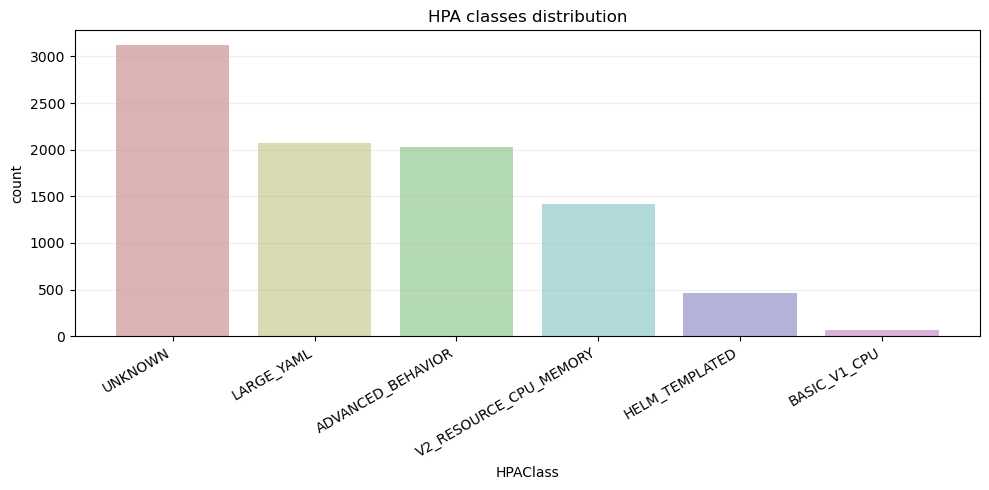

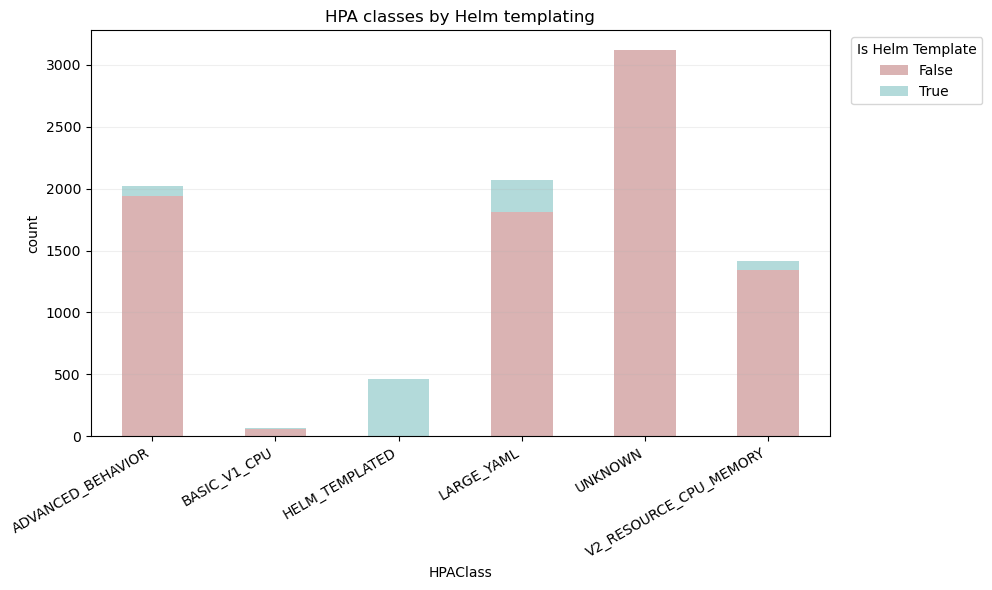

/tmp/ipykernel_14312/512556423.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(c) for c in order], patch_artist=True)


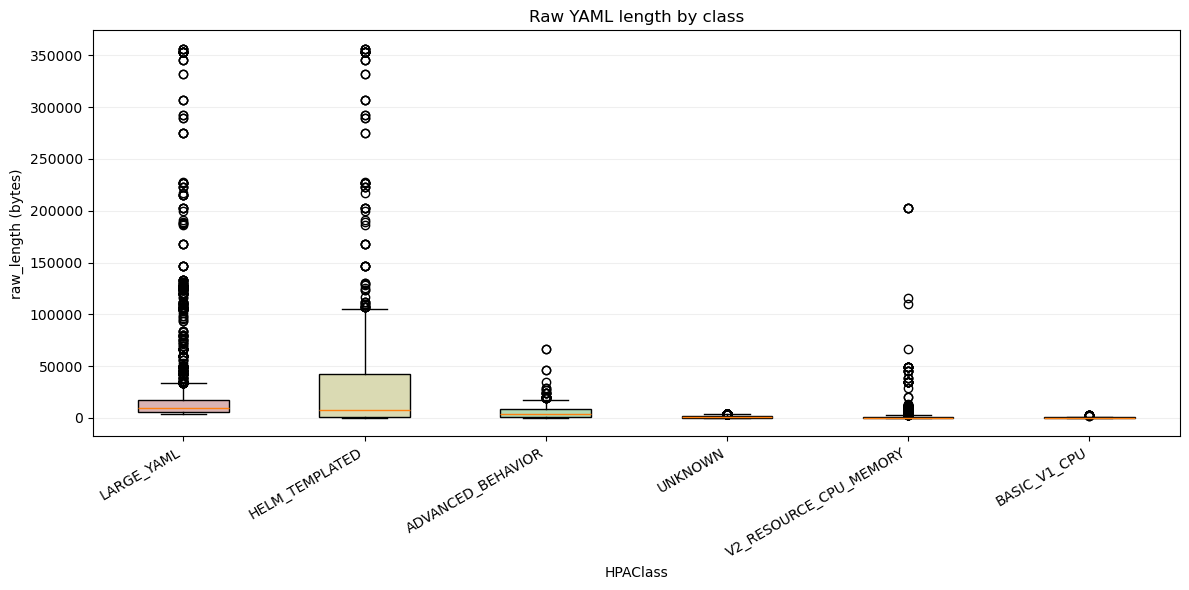

In [15]:

# ==== Pastel plots ====
if 'df_class' in globals() and not df_class.empty:
    # 1) Counts per class
    cnt = df_class.groupby("HPAClass").size().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(cnt.index.astype(str), cnt.values, color=_pastel(len(cnt)))
    ax.set_title("HPA classes distribution")
    ax.set_xlabel("HPAClass")
    ax.set_ylabel("count")
    ax.grid(axis="y", alpha=0.2)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # 2) Stacked by Helm
    pivot = (df_class.assign(is_helm=df_class[Col.IS_HELM].astype(bool))
                      .pivot_table(index="HPAClass", columns="is_helm", values=Col.FILE_PATH, aggfunc="count", fill_value=0))
    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(10,6))
        pivot.plot(kind="bar", stacked=True, ax=ax, color=_pastel(pivot.shape[1]))
        ax.set_title("HPA classes by Helm templating")
        ax.set_xlabel("HPAClass")
        ax.set_ylabel("count")
        ax.legend(title="Is Helm Template", bbox_to_anchor=(1.02,1), loc="upper left")
        ax.grid(axis="y", alpha=0.2)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    # 3) Raw YAML length distribution by class
    df_len = df_class.dropna(subset=["raw_length"])
    if not df_len.empty:
        order = df_len.groupby("HPAClass")["raw_length"].median().sort_values(ascending=False).index
        fig, ax = plt.subplots(figsize=(12,6))
        data = [df_len[df_len["HPAClass"]==cls]["raw_length"].values for cls in order]
        bp = ax.boxplot(data, labels=[str(c) for c in order], patch_artist=True)
        cols = _pastel(len(order))
        for patch, c in zip(bp['boxes'], cols):
            patch.set_facecolor(c)
        ax.set_title("Raw YAML length by class")
        ax.set_xlabel("HPAClass")
        ax.set_ylabel("raw_length (bytes)")
        ax.grid(axis="y", alpha=0.2)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()


In [16]:

# ==== Additional enums for centralized messages ====
from enum import Enum

class ErrorCode(Enum):
    NO_ARTIFACTS       = "E_NO_ARTIFACTS"
    BAD_SCHEMA         = "E_BAD_SCHEMA"
    EMPTY_RESULT       = "E_EMPTY_RESULT"

class WarnCode(Enum):
    LOW_SUPPORT_CLASS  = "W_LOW_SUPPORT_CLASS"
    MISSING_COLUMNS    = "W_MISSING_COLUMNS"
    SPARSE_IAC_SIGNALS = "W_SPARSE_IAC"


In [17]:

# ==== Data quality checks ====
def dq_summary():
    out = {}
    out["p2_rows"] = len(df_p2) if 'df_p2' in globals() else 0
    out["p3_rows"] = len(df_p3) if 'df_p3' in globals() else 0
    out["p4_rows"] = len(df_p4) if 'df_p4' in globals() else 0
    out["class_rows"] = len(df_class) if 'df_class' in globals() else 0
    out["repos_with_class"] = df_class["repo_full_name"].nunique() if 'df_class' in globals() and not df_class.empty else 0
    return out

dq = dq_summary()
log.info("DQ: %s", dq)
display(dq)
if dq["class_rows"] == 0:
    log.warning("%s no classified rows", ErrorCode.EMPTY_RESULT.value)


2025-10-08 11:06:53,072 - hpa_classify - INFO - DQ: {'p2_rows': 8182, 'p3_rows': 4949, 'p4_rows': 7641, 'class_rows': 9164, 'repos_with_class': 3725}


{'p2_rows': 8182,
 'p3_rows': 4949,
 'p4_rows': 7641,
 'class_rows': 9164,
 'repos_with_class': 3725}

/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 29982 (\N{CJK UNIFIED IDEOGRAPH-751E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 35856 (\N{CJK UNIFIED IDEOGRAPH-8C10}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 39051 (\N{CJK UNIFIED IDEOGRAPH-988B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 26506 (\N{CJK UNIFIED IDEOGRAPH-678A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 34893 (\N{CJK UNIFIED IDEOGRAPH-884D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 34351 (\N{CJK UNIFIED IDEOGRAPH-862F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14312/1949779742.py:70: UserWarning: Glyph 22840 (\N{CJK UNIFIED IDEOGRAP

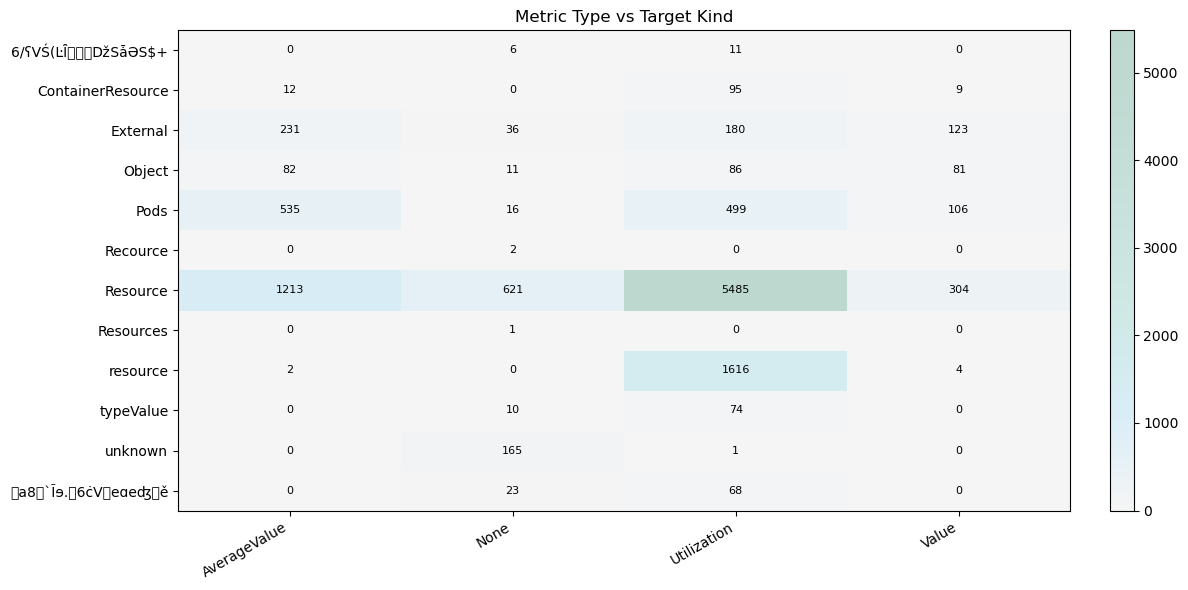

In [18]:
# Heatmap: Metric Type vs Target Kind, robusto a colunas ausentes

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def pastel_cmap(n=256):
    colors = ["#f5f5f5","#d9edf7","#cfe9e6","#c9e2dd","#c2dbd4","#bdd8cf"]
    return LinearSegmentedColormap.from_list("pastel_custom", colors, N=n)

def build_heatmap_base(df_class: pd.DataFrame, df_p4: pd.DataFrame) -> pd.DataFrame:
    if df_class.empty:
        return pd.DataFrame(columns=["Metric Type","Target Kind","repo_full_name"])
    base = df_class.copy()

    # Garante Metric Type
    if "Metric Type" not in base.columns:
        base["Metric Type"] = np.nan

    # Garante Target Kind unindo com p4 quando disponível
    if "Target Kind" not in base.columns:
        if "Target Kind" in df_p4.columns:
            # Chave mais estável: repo_full_name + File Path
            cols = ["repo_full_name", "File Path", "Target Kind"]
            cols = [c for c in cols if c in df_p4.columns]
            left_on = [c for c in ["repo_full_name","File Path"] if c in base.columns]
            right_on = [c for c in ["repo_full_name","File Path"] if c in df_p4.columns]
            if left_on and right_on:
                base = base.merge(df_p4[cols].drop_duplicates(), on=list(set(left_on) & set(right_on)), how="left")
            else:
                # fallback sem File Path
                if "repo_full_name" in base.columns and "repo_full_name" in df_p4.columns:
                    tk_by_repo = (df_p4.groupby("repo_full_name")["Target Kind"]
                                       .agg(lambda s: s.dropna().iloc[0] if not s.dropna().empty else np.nan)
                                       .reset_index())
                    base = base.merge(tk_by_repo, on="repo_full_name", how="left")
        else:
            base["Target Kind"] = np.nan

    # Normaliza Target Kind
    base["Target Kind"] = base["Target Kind"].fillna("None").astype(str)
    # Normaliza Metric Type
    base["Metric Type"] = base["Metric Type"].fillna("unknown").astype(str)
    return base

if 'df_class' in globals() and not df_class.empty:
    base = build_heatmap_base(df_class, df_p4 if 'df_p4' in globals() else pd.DataFrame())
    if not base.empty:
        tab = base.pivot_table(
            index="Metric Type",
            columns="Target Kind",
            values="repo_full_name",
            aggfunc="count",
            fill_value=0
        ).sort_index()

        if not tab.empty:
            fig, ax = plt.subplots(figsize=(12, 6))
            im = ax.imshow(tab.values, cmap=pastel_cmap(), aspect="auto")
            ax.set_xticks(range(tab.shape[1]))
            ax.set_xticklabels(tab.columns, rotation=30, ha="right")
            ax.set_yticks(range(tab.shape[0]))
            ax.set_yticklabels(tab.index)
            ax.set_title("Metric Type vs Target Kind")
            # Anotações
            for i in range(tab.shape[0]):
                for j in range(tab.shape[1]):
                    ax.text(j, i, str(int(tab.values[i, j])), ha="center", va="center", fontsize=8)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            plt.tight_layout()
            plt.show()
        else:
            print("Tabela vazia após pivot. Verifique se existem Metric Type e Target Kind válidos.")
    else:
        print("Base vazia para o heatmap. Rode as fases anteriores e a classificação.")
else:
    print("df_class não está disponível ou está vazio.")


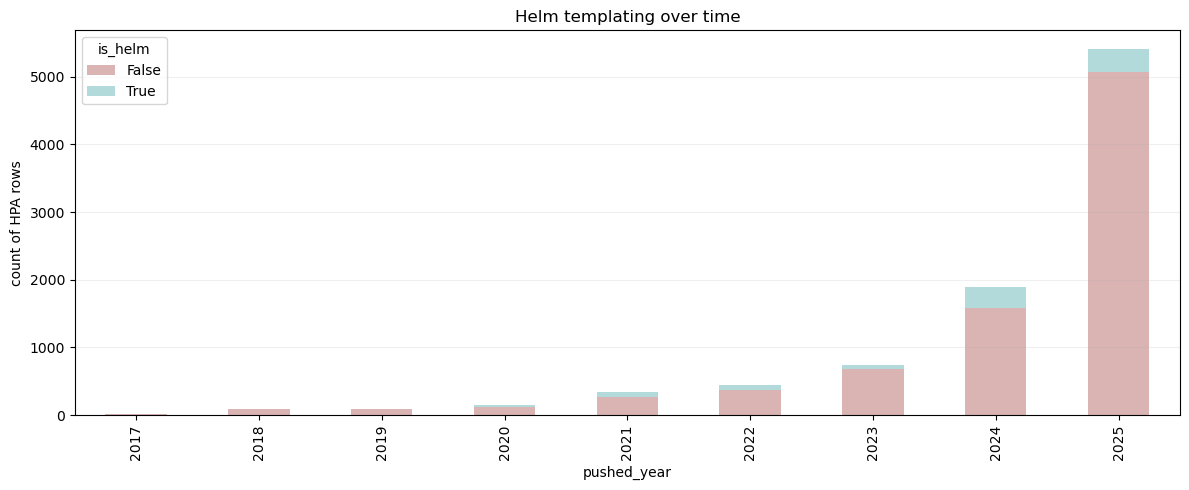

In [19]:

# ==== Helm usage over time (by pushed_year) ====
if 'df_p2' in globals() and 'df_class' in globals() and not df_class.empty and not df_p2.empty:
    # join pushed_year
    df_p2["pushed_year"] = pd.to_datetime(df_p2["pushed_at"], errors="coerce", utc=True).dt.year
    tmp = df_class.merge(df_p2[["repo_full_name","pushed_year"]], on="repo_full_name", how="left")
    pv = (tmp.assign(is_helm=tmp[Col.IS_HELM].astype(bool))
              .groupby(["pushed_year","is_helm"]).size().unstack(fill_value=0).sort_index())
    if not pv.empty:
        ax = pv.plot(kind="bar", stacked=True, figsize=(12,5), color=_pastel(pv.shape[1]))
        ax.set_title("Helm templating over time")
        ax.set_xlabel("pushed_year")
        ax.set_ylabel("count of HPA rows")
        ax.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()


In [20]:

# ==== Behavior usage by apiVersion major ====
if 'df_class' in globals() and not df_class.empty:
    base = df_class.copy()
    base["major"] = base[Col.APIVERSION].astype(str).str.extract(r'(v\\d)')
    pv = (base.groupby(["major"])["Has Behavior"].mean().fillna(0.0) * 100.0)
    if not pv.empty:
        fig, ax = plt.subplots(figsize=(8,4))
        ax.bar(pv.index.astype(str), pv.values, color=_pastel(len(pv)))
        ax.set_title("Behavior usage rate by apiVersion major")
        ax.set_xlabel("apiVersion major")
        ax.set_ylabel("repos with behavior (%)")
        ax.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()


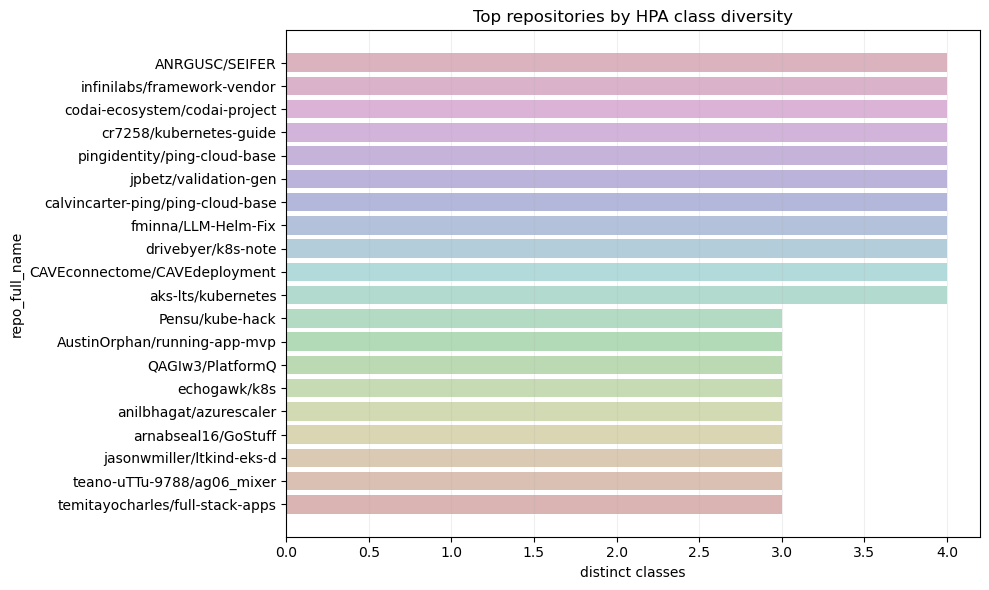

In [21]:

# ==== Metric diversity per repo, top 20 ====
if 'df_class' in globals() and not df_class.empty:
    div = (df_class.groupby("repo_full_name")["HPAClass"].nunique()
                  .sort_values(ascending=False).head(20))
    if not div.empty:
        fig, ax = plt.subplots(figsize=(10,6))
        ax.barh(div.index[::-1], div.values[::-1], color=_pastel(len(div)))
        ax.set_title("Top repositories by HPA class diversity")
        ax.set_xlabel("distinct classes")
        ax.set_ylabel("repo_full_name")
        ax.grid(axis="x", alpha=0.2)
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_14312/444037574.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


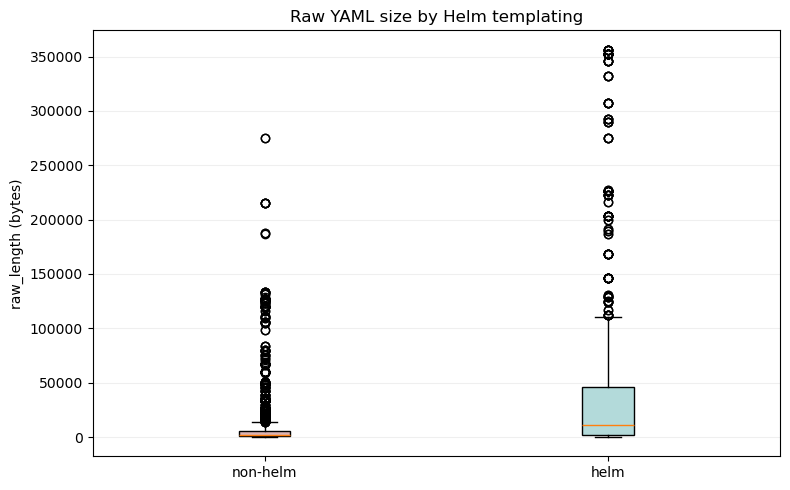

In [22]:

# ==== Raw YAML length distribution by Helm flag ====
if 'df_class' in globals() and not df_class.empty:
    d = df_class.dropna(subset=["raw_length"]).copy()
    if not d.empty:
        d["is_helm"] = d[Col.IS_HELM].astype(bool)
        groups = [d[d["is_helm"]==False]["raw_length"].values, d[d["is_helm"]==True]["raw_length"].values]
        labels = ["non-helm","helm"]
        fig, ax = plt.subplots(figsize=(8,5))
        bp = ax.boxplot(groups, labels=labels, patch_artist=True)
        cols = _pastel(2)
        for patch, c in zip(bp['boxes'], cols):
            patch.set_facecolor(c)
        ax.set_title("Raw YAML size by Helm templating")
        ax.set_ylabel("raw_length (bytes)")
        ax.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()


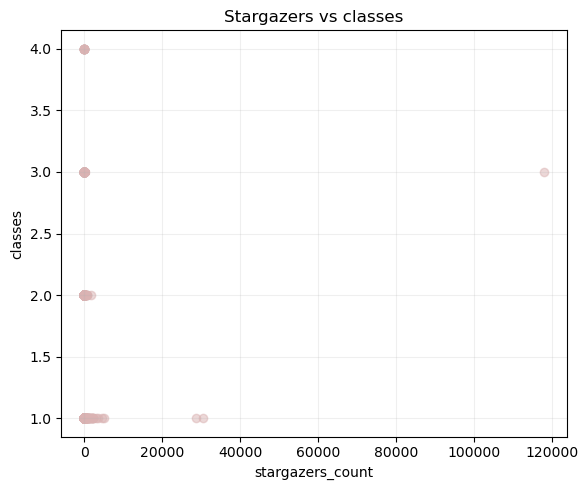

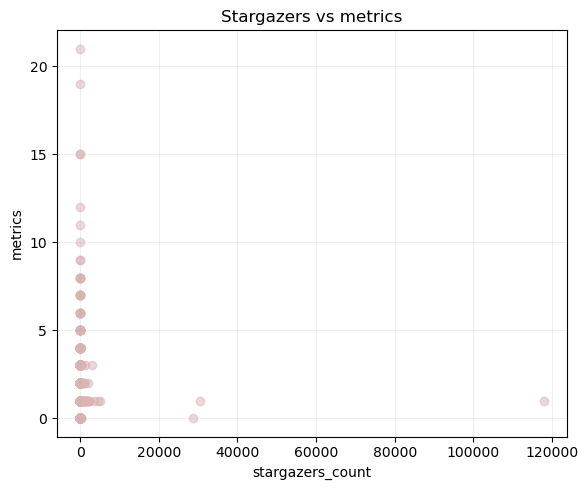

In [23]:

# ==== Correlation: stars vs metrics/class richness ====
if 'df_p2' in globals() and 'df_class' in globals() and not df_class.empty and not df_p2.empty:
    richness = (df_class.groupby("repo_full_name").agg(
                    classes=("HPAClass","nunique"),
                    metrics=("Metric Name","nunique")
                ).reset_index())
    joined = richness.merge(df_p2[["repo_full_name","stargazers_count"]], on="repo_full_name", how="left")
    joined["stargazers_count"] = pd.to_numeric(joined["stargazers_count"], errors="coerce").fillna(0.0)
    for col in ["classes","metrics"]:
        fig, ax = plt.subplots(figsize=(6,5))
        ax.scatter(joined["stargazers_count"], joined[col], alpha=0.5, c=_pastel(1)[0])
        ax.set_title(f"Stargazers vs {col}")
        ax.set_xlabel("stargazers_count")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_14312/2663782635.py:20: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  vals = series.view("int64") // 10**9


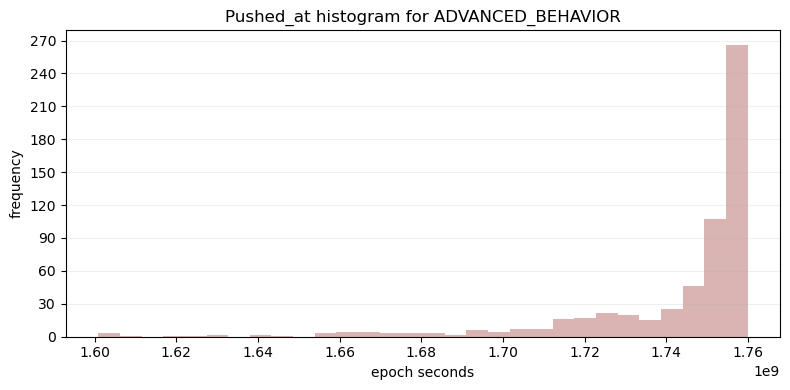

/tmp/ipykernel_14312/2663782635.py:20: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  vals = series.view("int64") // 10**9


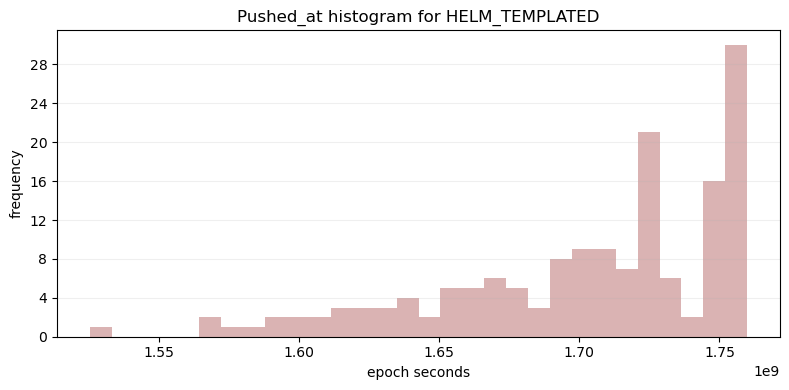

/tmp/ipykernel_14312/2663782635.py:20: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  vals = series.view("int64") // 10**9


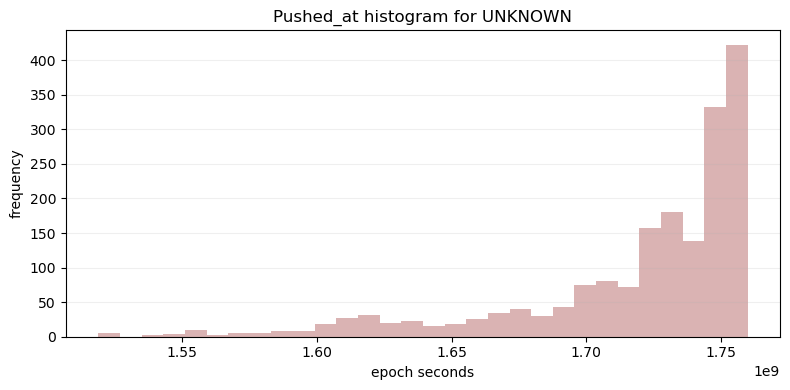

/tmp/ipykernel_14312/2663782635.py:20: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  vals = series.view("int64") // 10**9


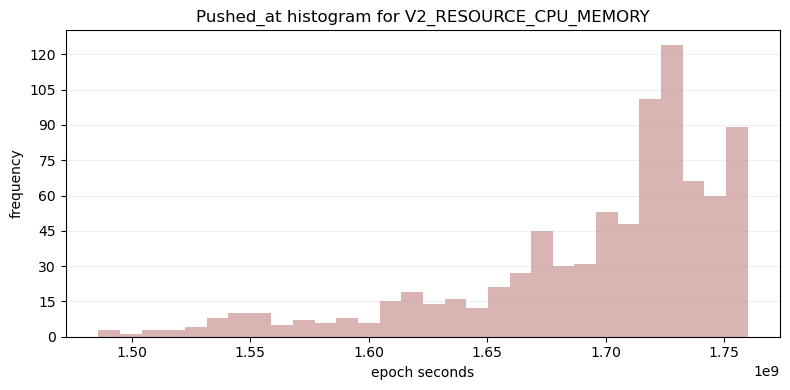

/tmp/ipykernel_14312/2663782635.py:20: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  vals = series.view("int64") // 10**9


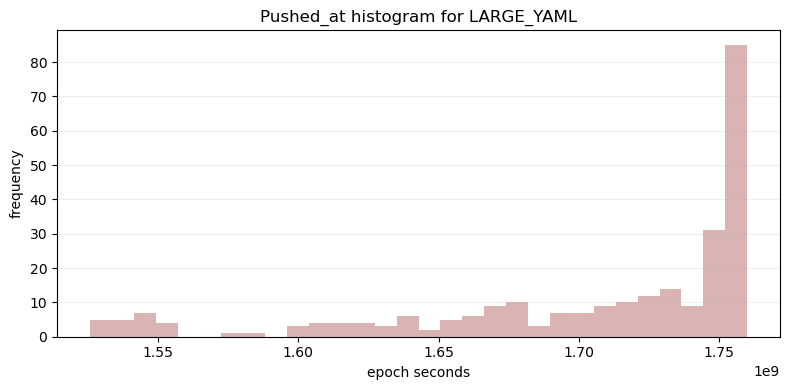

/tmp/ipykernel_14312/2663782635.py:20: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  vals = series.view("int64") // 10**9


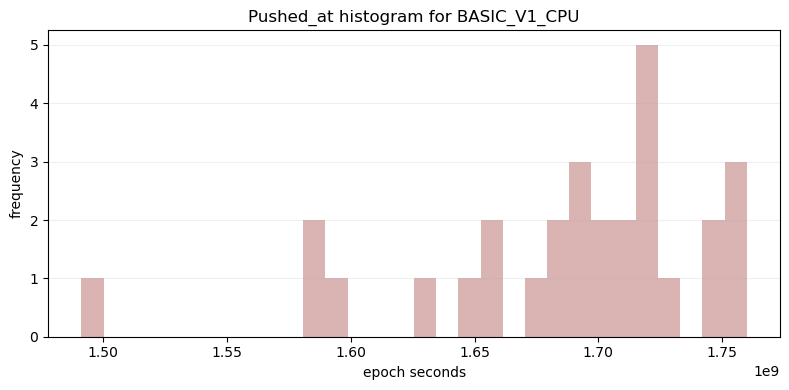

In [24]:

# ==== Timeline histogram of pushed_at by dominant class ====
if 'df_p2' in globals() and 'df_class' in globals() and not df_class.empty and not df_p2.empty:
    # dominant class per repo = most frequent class
    dom = (df_class.groupby(["repo_full_name","HPAClass"]).size()
                   .reset_index(name="n")
                   .sort_values(["repo_full_name","n"], ascending=[True,False])
                   .drop_duplicates("repo_full_name"))
    base = dom.merge(df_p2[["repo_full_name","pushed_at"]], on="repo_full_name", how="left")
    base["pushed_at"] = pd.to_datetime(base["pushed_at"], errors="coerce", utc=True)
    base = base.dropna(subset=["pushed_at"])
    if not base.empty:
        # per class hist
        classes = base["HPAClass"].unique().tolist()
        for cls in classes:
            series = base.loc[base["HPAClass"]==cls, "pushed_at"].sort_values()
            if series.empty:
                continue
            fig, ax = plt.subplots(figsize=(8,4))
            # epoch seconds for bins
            vals = series.view("int64") // 10**9
            pastel_hist(ax, vals, bins=30, title=f"Pushed_at histogram for {cls}", xlabel="epoch seconds")
            plt.tight_layout()
            plt.show()


In [25]:
# ==== Pastel plots: v2 metrics stacked (log), v2 excluding Resource, dates scatter com releases ====

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter, MaxNLocator
import matplotlib.dates as mdates

# Paleta pastel consistente
def _pastel(n: int):
    import colorsys
    base = []
    for i in range(max(1, n)):
        hue = i / max(1, n)
        light = 0.78
        sat = 0.35
        r, g, b = colorsys.hls_to_rgb(hue, light, sat)
        base.append("#{0:02x}{1:02x}{2:02x}".format(int(r*255), int(g*255), int(b*255)))
    return base[:n]

# Silencia avisos de glifos ausentes em fontes
warnings.filterwarnings("ignore", message="Glyph .* missing from font\\(s\\)")
plt.rcParams["axes.unicode_minus"] = False

# 1) Normaliza base para gráficos
def _normalize_metrics_frame(_dfc: pd.DataFrame) -> pd.DataFrame:
    if _dfc is None or _dfc.empty:
        return pd.DataFrame(columns=["repo_full_name", "apiVersion", "metric_type", "metric_name", "Is Helm Template"])
    df = _dfc.copy()
    # mapeia para snake_case esperado nos trechos originais
    if "Metric Type" in df.columns and "Metric Name" in df.columns:
        df = df.rename(columns={"Metric Type": "metric_type", "Metric Name": "metric_name"})
    if "apiVersion" not in df.columns and "apiVersion" in df.columns:
        df["apiVersion"] = df["apiVersion"]
    # garante colunas
    for c in ["repo_full_name", "apiVersion", "metric_type", "metric_name", "Is Helm Template"]:
        if c not in df.columns:
            df[c] = np.nan
    # strings limpas
    for c in ["apiVersion","metric_type","metric_name"]:
        df[c] = df[c].astype(str)
    return df

dfc_norm = _normalize_metrics_frame(df_class if "df_class" in globals() else pd.DataFrame())

# Filtro sem Helm
if not dfc_norm.empty:
    filter_nohelm = dfc_norm[dfc_norm["Is Helm Template"].astype(bool) == False].copy()
else:
    filter_nohelm = pd.DataFrame(columns=dfc_norm.columns)

# 2) Plot: v2 metrics stacked com escala log
def plot_v2_stacked_log(_df: pd.DataFrame, title: str):
    if _df.empty:
        print("Sem dados para o gráfico:", title)
        return
    df_v2 = _df[_df["apiVersion"].str.contains(r"\bv2", na=False, case=False)]
    if df_v2.empty:
        print("Sem linhas v2 para o gráfico:", title)
        return

    v2_metrics = df_v2.groupby(["metric_type", "metric_name"]).size().reset_index(name="counts")
    pivot_table = v2_metrics.pivot(index="metric_type", columns="metric_name", values="counts").fillna(0)

    if pivot_table.empty:
        print("Pivot vazio para o gráfico:", title)
        return

    ax = pivot_table.plot(kind="bar", stacked=True, figsize=(12, 6), color=_pastel(len(pivot_table.columns)))
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 4]))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.set_title(title)
    ax.set_xlabel("metric_type")
    ax.set_ylabel("Metric Name Count (log)")
    ax.legend(title="metric_name", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
    ax.grid(axis="y", alpha=0.2)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_14312/2603101362.py:80: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


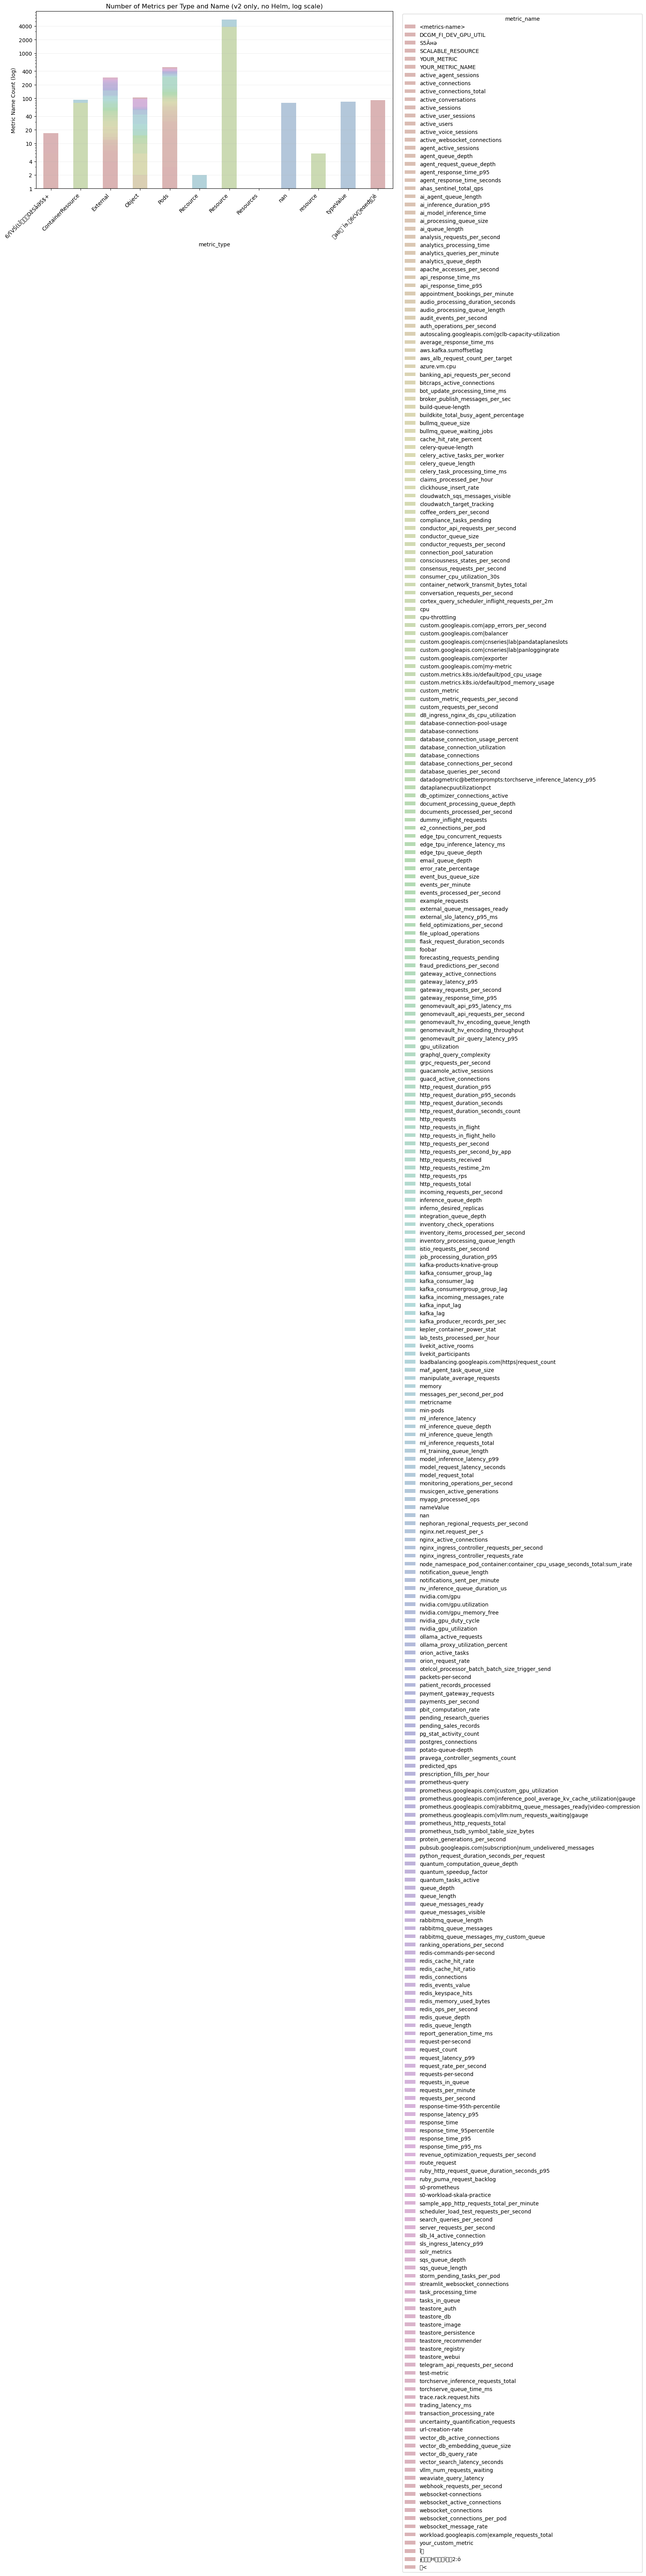

In [26]:
# 3) Plot: v2 metrics stacked excluindo Resource
def plot_v2_stacked_excl_resource(_df: pd.DataFrame, title: str):
    if _df.empty:
        print("Sem dados para o gráfico:", title)
        return
    df_v2 = _df[_df["apiVersion"].str.contains(r"\bv2", na=False, case=False)]
    if df_v2.empty:
        print("Sem linhas v2 para o gráfico:", title)
        return

    # Remove resource, tanto 'resource' quanto 'Resource'
    df_v2_no_resource = df_v2[df_v2["metric_type"].str.lower() != "resource"]
    if df_v2_no_resource.empty:
        print("Sem dados após excluir Resource para o gráfico:", title)
        return

    v2_metrics = df_v2_no_resource.groupby(["metric_type", "metric_name"]).size().reset_index(name="counts")
    pivot_table = v2_metrics.pivot(index="metric_type", columns="metric_name", values="counts").fillna(0)

    ax = pivot_table.plot(kind="bar", stacked=True, figsize=(12, 6), color=_pastel(len(pivot_table.columns)))
    ax.set_title(title)
    ax.set_xlabel("metric_type")
    ax.set_ylabel("Metric Name Count")
    ax.legend(title="metric_name", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
    ax.grid(axis="y", alpha=0.2)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Executa os dois gráficos
plot_v2_stacked_log(filter_nohelm, "Number of Metrics per Type and Name (v2 only, no Helm, log scale)")

/tmp/ipykernel_14312/707535225.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


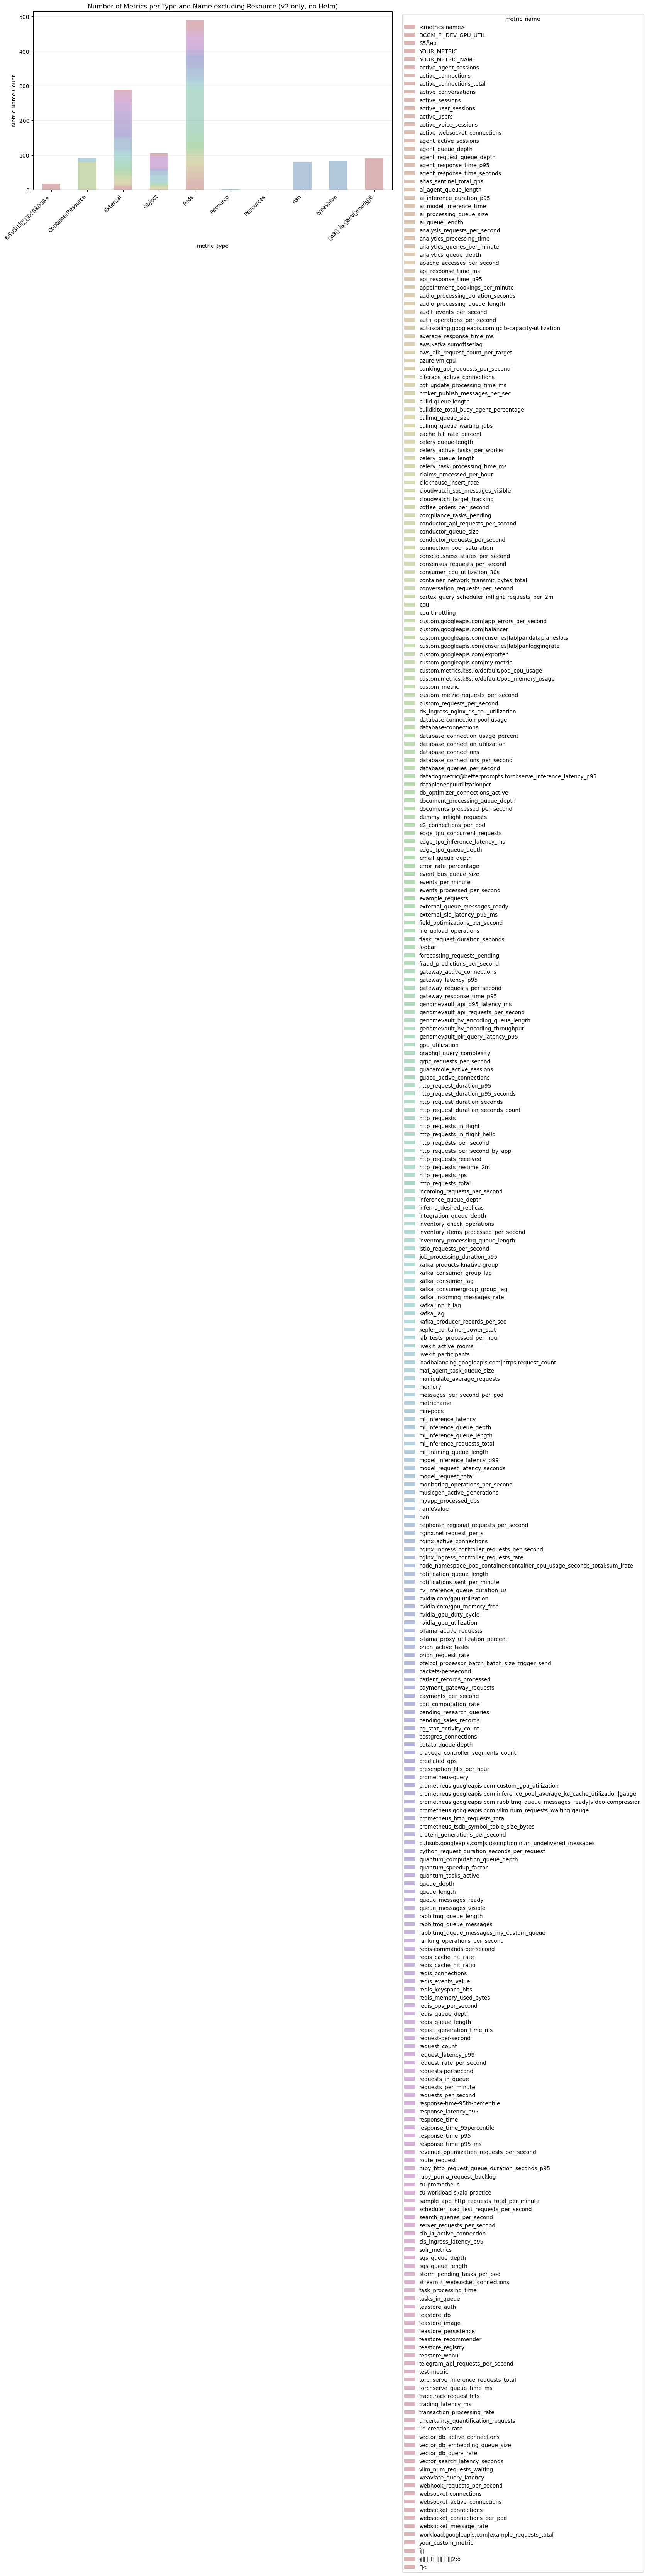

In [27]:
plot_v2_stacked_excl_resource(filter_nohelm, "Number of Metrics per Type and Name excluding Resource (v2 only, no Helm)")

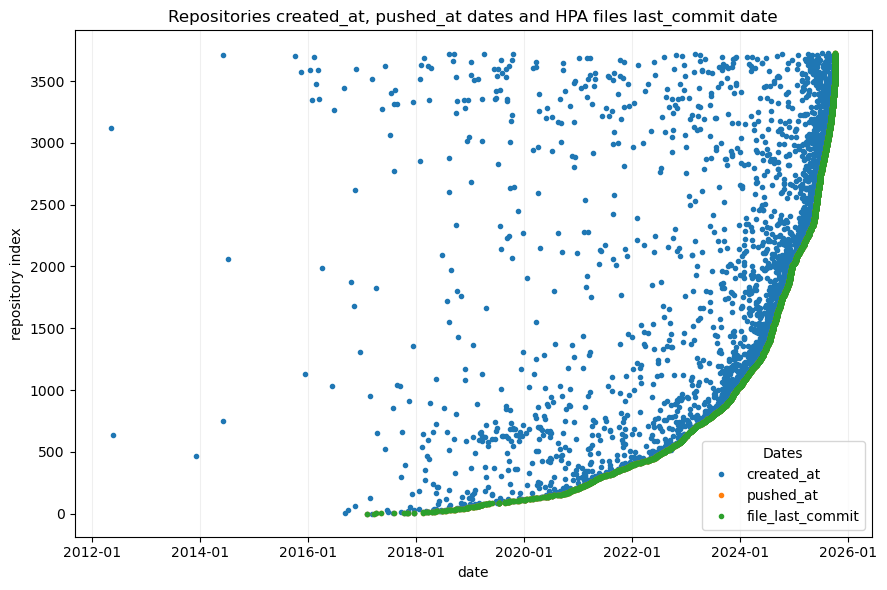

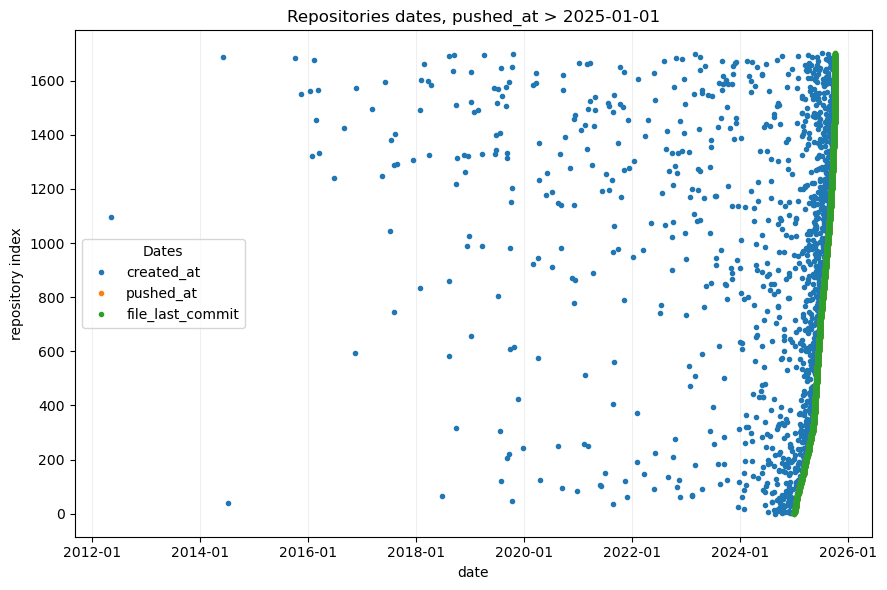

In [28]:

# 4) Scatter de datas com linhas de release do HPA
def ensure_items_details() -> pd.DataFrame:
    # Tenta usar df5, senão phase5_latest, senão phase2
    if "items_details" in globals() and isinstance(items_details, pd.DataFrame) and not items_details.empty:
        base = items_details.copy()
    elif "df5" in globals() and isinstance(df5, pd.DataFrame) and not df5.empty:
        base = df5[["repo_full_name","created_at","pushed_at"]].drop_duplicates("repo_full_name").rename(columns={"repo_full_name":"repo_name"}).copy()
    else:
        # tenta carregar CSVs
        def _latest_csv(dir_path: Path, tag: str) -> Path | None:
            files = sorted((dir_path / "partial_results").glob(f"*-{tag}.csv"))
            if files:
                return files[-1]
            alias = (dir_path / f"{tag}_latest.csv")
            return alias if alias.exists() else None
        _DATA_DIR = DATA_DIR if "DATA_DIR" in globals() else Path("data")
        p5 = _latest_csv(_DATA_DIR, "phase5")
        if p5 and p5.exists() and p5.stat().st_size > 0:
            tmp = pd.read_csv(p5)
            rn = tmp["repo_full_name"] if "repo_full_name" in tmp.columns else None
            base = tmp[["repo_full_name","created_at","pushed_at"]].drop_duplicates("repo_full_name").rename(columns={"repo_full_name":"repo_name"}).copy()
        else:
            p2 = _latest_csv(_DATA_DIR, "phase2")
            if not p2:
                raise RuntimeError("Sem dados para montar items_details. Rode phase2 ou phase5.")
            tmp = pd.read_csv(p2)
            base = tmp[["repo_full_name","created_at","pushed_at"]].drop_duplicates("repo_full_name").rename(columns={"repo_full_name":"repo_name"}).copy()

    # Converte para datetime
    base["created_at"] = pd.to_datetime(base["created_at"], errors="coerce", utc=True)
    base["pushed_at"]  = pd.to_datetime(base["pushed_at"], errors="coerce", utc=True)

    # Garante file_last_commit. Se inexistente, usa pushed_at como proxy segura.
    if "file_last_commit" not in base.columns:
        base["file_last_commit"] = base["pushed_at"]
    else:
        base["file_last_commit"] = pd.to_datetime(base["file_last_commit"], errors="coerce", utc=True)
        base["file_last_commit"] = base["file_last_commit"].fillna(base["pushed_at"])

    return base

def dates_scatter_plot(df: pd.DataFrame,
                       releasedate_hpav1=None,
                       releasedate_hpav2beta1=None,
                       releasedate_hpav2beta2=None,
                       releasedate_hpav2=None,
                       title="Repositories created_at, pushed_at dates and HPA files last_commit date"):
    if df.empty:
        print("Sem dados para o scatter de datas.")
        return

    fig, ax = plt.subplots(figsize=(9, 6))

    # Linhas verticais de releases, somente se fornecidas
    colors = _pastel(8)
    rels = [
        ("HPA v1", releasedate_hpav1, 4),
        ("HPA v2beta1", releasedate_hpav2beta1, 5),
        ("HPA v2beta2", releasedate_hpav2beta2, 6),
        ("HPA v2", releasedate_hpav2, 7),
    ]
    for lbl, dt, idx in rels:
        if dt is not None:
            ax.axvline(pd.to_datetime(dt, utc=True), label=lbl, linestyle="--", linewidth=1.2)

    # Index serve como eixo Y categórico estável
    ax.plot(df["created_at"], df.index, marker=".", linestyle="", label="created_at")
    ax.plot(df["pushed_at"], df.index, marker=".", linestyle="", label="pushed_at")
    ax.plot(df["file_last_commit"], df.index, marker=".", linestyle="", label="file_last_commit")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_title(title)
    ax.set_xlabel("date")
    ax.set_ylabel("repository index")
    ax.grid(True, axis="x", alpha=0.2)
    ax.legend(title="Dates", loc="best")
    plt.tight_layout()
    plt.show()

# Monta items_details se preciso
try:
    _items = ensure_items_details().sort_values("pushed_at", ignore_index=True)
except Exception as e:
    print("Falha ao preparar items_details:", e)
    _items = pd.DataFrame(columns=["created_at","pushed_at","file_last_commit"])

# 5) Chama os scatters
dates_scatter_plot(_items)
# Filtro de janela temporal, se você quiser
_recent = _items[_items["pushed_at"] > pd.Timestamp("2025-01-01", tz="UTC")].sort_values("pushed_at", ignore_index=True)
if not _recent.empty:
    dates_scatter_plot(_recent, title="Repositories dates, pushed_at > 2025-01-01")
else:
    print("Sem repositórios com pushed_at > 2025-01-01 para o scatter filtrado.")

In [29]:

# ==== Sample examples per class with file links ====
def sample_examples_per_class(n=5) -> pd.DataFrame:
    if df_class.empty:
        return pd.DataFrame(columns=["HPAClass","repo_full_name","File Path","github_url"])
    # try to reconstruct url: we do not have html_url here, but we can form a GitHub link pattern
    def mk_url(repo, path):
        return f"https://github.com/{repo}/blob/HEAD/{path}"
    out = []
    for cls, grp in df_class.groupby("HPAClass"):
        g = grp.sample(n=min(n, len(grp)), random_state=42)
        for _, r in g.iterrows():
            out.append({
                "HPAClass": cls,
                "repo_full_name": r["repo_full_name"],
                "File Path": r[Col.FILE_PATH],
                "github_url": mk_url(r["repo_full_name"], r[Col.FILE_PATH])
            })
    return pd.DataFrame(out)

examples = sample_examples_per_class(5)
display(examples.head(20))


,HPAClass,repo_full_name,File Path,github_url
0,ADVANCED_BEHAVIOR,jashmhta/HMSSSS,infrastructure/istio/advanced-hpa.yaml,https://github.com/jashmhta/HMSSSS/blob/HEAD/i...
1,ADVANCED_BEHAVIOR,nheek/lookatme,k3s/hpa.yaml,https://github.com/nheek/lookatme/blob/HEAD/k3...
2,ADVANCED_BEHAVIOR,SomasekharSunkari/MicroService_Springboot,order/hpa.yml,https://github.com/SomasekharSunkari/MicroServ...
3,ADVANCED_BEHAVIOR,walessy/Progressive-Framework-v5,deploy/docker-compose.dev.yml,https://github.com/walessy/Progressive-Framewo...
4,ADVANCED_BEHAVIOR,evansims/rust-api,k8s/deployment.yaml,https://github.com/evansims/rust-api/blob/HEAD...
5,BASIC_V1_CPU,Le0exxx/ping-cloud-base,k8s-configs/ping-cloud/prod/large/pingfederate...,https://github.com/Le0exxx/ping-cloud-base/blo...
6,BASIC_V1_CPU,sc-test-organization/kubes-deployment-testing,pbrprod1/base/sso-oauth-authority/horizontalpo...,https://github.com/sc-test-organization/kubes-...
7,BASIC_V1_CPU,quay/quay-operator,e2e/hpa/02-bump-hpas.yaml,https://github.com/quay/quay-operator/blob/HEA...
8,BASIC_V1_CPU,wbrown-ping/ping-cloud-base,code-gen/templates/cde/base/ping-cloud/pingacc...,https://github.com/wbrown-ping/ping-cloud-base...
9,BASIC_V1_CPU,Mercor-Projects/Harsh4999-Bugtesting11,platforms/karaf/itests/src/test/resources/dese...,https://github.com/Mercor-Projects/Harsh4999-B...


In [39]:

# ==== Helpers: Helm template detection, YAML parsing, metrics and behavior extraction ====
import re, yaml
import pandas as pd
from yaml.loader import SafeLoader
from typing import Optional, List, Dict, Any

# ==== LogEvent shim: garante todos os eventos usados neste notebook ====
from enum import Enum

_REQUIRED_EVENTS = {
    "REQUEST_FAIL":       "REQUEST_FAIL",
    "PARSE_YAML_FAIL":    "PARSE_YAML_FAIL",
    "COMMITS_LIST_FAIL":  "COMMITS_LIST_FAIL",
    "RAW_DL_FAIL":        "RAW_DL_FAIL",
    "HISTORY_SAVE":       "HISTORY_SAVE",
}

def _ensure_logevent():
    global LogEvent
    if "LogEvent" not in globals():
        # cria uma classe simples com atributos de string
        class LogEvent:
            pass
        for k, v in _REQUIRED_EVENTS.items():
            setattr(LogEvent, k, v)
        globals()["LogEvent"] = LogEvent
        return

    # Já existe. Garante que todos os atributos estejam presentes.
    LE = globals()["LogEvent"]
    for k, v in _REQUIRED_EVENTS.items():
        if not hasattr(LE, k):
            try:
                # tenta setar no objeto existente
                setattr(LE, k, v)
            except Exception:
                # se for Enum e não permitir setattr, cria um wrapper leve
                class _LEWrapper:
                    pass
                for kk, vv in _REQUIRED_EVENTS.items():
                    setattr(_LEWrapper, kk, vv)
                globals()["LogEvent"] = _LEWrapper
                break

_ensure_logevent()

def LE(name: str) -> str:
    """Retorna a string do evento, compatível com Enum ou classe simples."""
    le = globals().get("LogEvent", None)
    if le is None:
        return name
    obj = getattr(le, name, None)
    # Se for Enum, pega .value. Se for string, retorna direto. Se ausente, retorna o nome.
    if obj is None:
        return name
    return getattr(obj, "value", obj)


def is_helm_template(content: str) -> bool:
    if not isinstance(content, str):
        return False
    if "{{" in content and "}}" in content:
        return True
    if "Release.Name" in content or "Values." in content:
        return True
    return False

def parse_yaml_documents(content: str) -> List[dict]:
    try:
        docs = list(yaml.load_all(content, Loader=SafeLoader))
        return [d for d in docs if isinstance(d, dict)]
    except yaml.YAMLError:
        return []

def extract_metrics_from_spec(spec: Dict[str, Any], debug: bool=False) -> List[Dict[str, Any]]:
    metrics_info: List[Dict[str, Any]] = []
    metrics = spec.get("metrics", []) or []
    for metric in metrics:
        if isinstance(metric, str):
            metrics_info.append({
                "metric_name": metric,
                "metric_type": metric,
                "target_value": metrics[metric] if isinstance(metrics, dict) and metric in metrics else None
            })
            continue
        if not isinstance(metric, dict):
            continue
        if "type" not in metric:
            if "CPUUtilizationPercentage" in spec:
                metrics_info.append({
                    "metric_name": "CPUUtilizationPercentage",
                    "metric_type": "CPUUtilizationPercentage",
                    "target_value": spec.get("CPUUtilizationPercentage")
                })
            continue
        mtype = metric.get("type","")
        block = metric.get(mtype.lower(), {}) if isinstance(metric.get(mtype.lower(), {}), dict) else {}
        target = block.get("target", {}) if isinstance(block.get("target", {}), dict) else {}
        target_value = (target.get("averageValue") or target.get("averageUtilization")
                        or target.get("targetAverageUtilization") or target.get("value"))
        if mtype.lower() == "resource":
            metric_name = block.get("name","")
        else:
            metric_name = block.get("metric", {}).get("name","")
        metrics_info.append({
            "metric_name": metric_name,
            "metric_type": mtype,
            "target_value": target_value
        })
    if not metrics:
        if "targetCPUUtilizationPercentage" in spec:
            metrics_info.append({
                "metric_name": "targetCPUUtilizationPercentage",
                "metric_type": "targetCPUUtilizationPercentage",
                "target_value": spec.get("targetCPUUtilizationPercentage")
            })
        if "cpuUtilization" in spec and isinstance(spec["cpuUtilization"], dict):
            metrics_info.append({
                "metric_name": "cpuUtilization",
                "metric_type": "cpuUtilization",
                "target_value": spec["cpuUtilization"].get("targetPercentage")
            })
    return metrics_info

def extract_behavior_from_spec(spec: Dict[str, Any], debug: bool=False) -> Optional[Dict[str, Any]]:
    behavior = spec.get("behavior")
    if not isinstance(behavior, dict):
        return None
    scale_up = behavior.get("scaleUp")
    scale_down = behavior.get("scaleDown")
    if scale_up is None and scale_down is None:
        return None
    res = {"scaleUp": None, "scaleDown": None}
    if isinstance(scale_up, dict):
        res["scaleUp"] = {
            "stab_window": scale_up.get("stabilizationWindowSeconds"),
            "select_pol": scale_up.get("selectPolicy"),
            "policies": [{
                "type": p.get("type",""),
                "value": p.get("value",0),
                "periodSeconds": p.get("periodSeconds",0)
            } for p in scale_up.get("policies",[]) if isinstance(p, dict)]
        }
    if isinstance(scale_down, dict):
        res["scaleDown"] = {
            "stab_window": scale_down.get("stabilizationWindowSeconds"),
            "select_pol": scale_down.get("selectPolicy"),
            "policies": [{
                "type": p.get("type",""),
                "value": p.get("value",0),
                "periodSeconds": p.get("periodSeconds",0)
            } for p in scale_down.get("policies",[]) if isinstance(p, dict)]
        }
    return res

def process_yaml_content(content: str, debug: bool=False) -> List[Dict[str, Any]]:
    helm_template = is_helm_template(content)
    if helm_template:
        return [{
            "hpa_count": 0,
            "apiVersion": None,
            "is_helm_template": True
        }]
    docs = parse_yaml_documents(content)
    out = []
    for doc in docs:
        if not isinstance(doc, dict):
            continue
        if doc.get("kind") != "HorizontalPodAutoscaler":
            continue
        api_version = doc.get("apiVersion","")
        spec = doc.get("spec", {}) if isinstance(doc.get("spec"), dict) else {}
        metrics = extract_metrics_from_spec(spec, debug=debug)
        behavior = extract_behavior_from_spec(spec, debug=debug)
        out.append({
            "hpa_count": len(out)+1,
            "apiVersion": api_version,
            "is_helm_template": helm_template,
            "Metrics": metrics,
            "Behavior": behavior
        })
    return out

def map_version(api_version: str) -> str:
    s = str(api_version or "").lower()
    if "v1" in s and "v2" not in s:
        return "v1"
    return "v2"


In [41]:

# ==== Commit history listing and file history download ====
import os, time
from pathlib import Path
from typing import Optional, Dict, Any, List

if 'gh' not in globals():
    import requests
    from requests.adapters import HTTPAdapter
    from urllib3.util.retry import Retry
    class GitHubClient:
        def __init__(self, token: Optional[str] = None):
            self.session = requests.Session()
            retries = Retry(total=5, backoff_factor=0.5, status_forcelist=[429,500,502,503,504])
            self.session.mount("https://", HTTPAdapter(max_retries=retries))
            self.base = "https://api.github.com"
            self.headers = {
                "Accept": "application/vnd.github+json",
                "X-GitHub-Api-Version": "2022-11-28",
                "User-Agent": "hpa-classify-notebook"
            }
            if token:
                self.headers["Authorization"] = f"token {token}"
        def get(self, path: str, params: Optional[dict]=None) -> dict:
            url = self.base + path
            r = self.session.get(url, headers=self.headers, params=params, timeout=30)
            r.raise_for_status()
            return r.json()
    GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
    gh = GitHubClient(GITHUB_TOKEN)

PROJ_DIR    = Path(".").resolve()
DATA_DIR    = PROJ_DIR / "data"
PARTIAL_DIR = DATA_DIR / "partial_results"
HISTORY_DIR = DATA_DIR / "repos_history"
for d in [DATA_DIR, PARTIAL_DIR, HISTORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import logging, sys
if 'log' not in globals():
    log = logging.getLogger("hpa_classify_2")
    if not log.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("%(asctime)s - hpa_classify_2 - %(levelname)s - %(message)s"))
        log.addHandler(h)
    log.setLevel(logging.INFO)

try:
    LogEvent
except NameError:
    class LogEvent:
        COMMITS_LIST_FAIL = "COMMITS_LIST_FAIL"
        RAW_DL_FAIL = "RAW_DL_FAIL"
        HISTORY_SAVE = "HISTORY_SAVE"

def _split_owner_repo(repo_full_name: str) -> tuple[str,str]:
    parts = str(repo_full_name).split("/", 1)
    return (parts[0], parts[1]) if len(parts) == 2 else (repo_full_name, "")

def list_file_commits(repo_full_name: str, path_in_repo: str, per_page: int=100, max_pages: int=10) -> List[dict]:
    owner, repo = _split_owner_repo(repo_full_name)
    commits: List[dict] = []
    for page in range(1, max_pages+1):
        try:
            data = gh.get(f"/repos/{owner}/{repo}/commits", params={"path": path_in_repo, "per_page": per_page, "page": page})
        except Exception as e:
            log.warning("%s %s/%s %s", LogEvent.COMMITS_LIST_FAIL, owner, repo, e)
            break
        if not isinstance(data, list) or not data:
            break
        commits.extend(data)
        if len(data) < per_page:
            break
        time.sleep(0.2)
    return commits

def file_first_last_commit(repo_full_name: str, path_in_repo: str) -> dict:
    commits = list_file_commits(repo_full_name, path_in_repo, per_page=100, max_pages=10)
    if not commits:
        return {"file_first_commit": None, "file_last_commit": None}
    last = commits[0]
    first = commits[-1]
    return {
        "file_first_commit": first.get("commit", {}).get("author", {}).get("date"),
        "file_last_commit": last.get("commit", {}).get("author", {}).get("date")
    }

def download_file_history(repo_full_name: str, path_in_repo: str, limit_commits: int=50) -> int:
    commits = list_file_commits(repo_full_name, path_in_repo, per_page=100, max_pages=10)
    if not commits:
        return 0
    owner, repo = _split_owner_repo(repo_full_name)
    saved = 0
    for commit in commits[:max(1, int(limit_commits))]:
        sha = commit.get("sha")
        date = commit.get("commit", {}).get("author", {}).get("date")
        if not sha or not date:
            continue
        url = f"https://raw.githubusercontent.com/{owner}/{repo}/{sha}/{path_in_repo}"
        try:
            resp = gh.session.get(url, timeout=30)
            if resp.status_code != 200:
                continue
            target_path = HISTORY_DIR / owner / repo / f"{date}" / path_in_repo
            target_path.parent.mkdir(parents=True, exist_ok=True)
            target_path.write_bytes(resp.content)
            saved += 1
            if saved % 20 == 0:
                log.info("%s %s", LogEvent.HISTORY_SAVE, target_path.as_posix())
        except Exception as e:
            log.warning("%s %s %s", LogEvent.RAW_DL_FAIL, url, e)
        time.sleep(0.1)
    return saved



# ==== High-volume history downloader: union Phase1+Phase3, sharding, resume, concurrency ====
import os, json, time, math, hashlib, threading
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# Parâmetros principais
MAX_WORKERS          = min((os.cpu_count() or 4) * 2, 16)   # paralelismo moderado
LIMIT_COMMITS_FILE   = 50                                   # versões por arquivo
CHECKPOINT_EVERY     = 100                                  # grava checkpoint a cada N arquivos concluídos
MAX_FILES_TOTAL      = None                                 # None para ilimitado, ou um inteiro para cap
REQUESTS_PER_SECOND  = 3.0                                  # throttle simples contra rate-limit
WIDEN_FILE_GLOBS     = True                                 # amplia o filtro para pegar .json, .tpl, .tmpl também

# Sharding opcional, para rodar em sessões distintas sem colisão
# Ex.: SHARD_MOD=5, SHARD_REM=0...4 para dividir em 5 fatias
SHARD_MOD = int(os.getenv("HPA_SHARD_MOD", "1"))
SHARD_REM = int(os.getenv("HPA_SHARD_REM", "0"))

CURSOR_PATH   = PARTIAL_DIR / "history_cursor.json"
RESULTS_PATH  = PARTIAL_DIR / "history_results_latest.csv"
HISTORY_DIR   = DATA_DIR / "repos_history"

# Throttle simples com token bucket aproximado
_last_req = [0.0]
_lock = threading.Lock()
def _throttle():
    if REQUESTS_PER_SECOND is None or REQUESTS_PER_SECOND <= 0:
        return
    with _lock:
        interval = 1.0 / REQUESTS_PER_SECOND
        now = time.time()
        dt = now - _last_req[0]
        if dt < interval:
            time.sleep(interval - dt)
        _last_req[0] = time.time()

# 1) Constrói a lista de arquivos a partir de Phase3 e Phase1
def _files_from_phase3(df_p3: pd.DataFrame) -> pd.DataFrame:
    if df_p3 is None or df_p3.empty:
        return pd.DataFrame(columns=["repo_full_name", "path_in_repo"])
    if "File Path" not in df_p3.columns:
        return pd.DataFrame(columns=["repo_full_name", "path_in_repo"])
    out = (df_p3[["repo_full_name", "File Path"]]
               .drop_duplicates()
               .rename(columns={"File Path": "path_in_repo"}))
    return out

def _files_from_phase1() -> pd.DataFrame:
    # Lê o phase1 mais recente, se existir
    files = sorted(PARTIAL_DIR.glob("*-phase1.csv"))
    if not files:
        return pd.DataFrame(columns=["repo_full_name", "path_in_repo"])
    p = files[-1]
    try:
        df1 = pd.read_csv(p)
        if not {"repo_full_name","path"}.issubset(df1.columns):
            return pd.DataFrame(columns=["repo_full_name", "path_in_repo"])
        return df1[["repo_full_name","path"]].drop_duplicates().rename(columns={"path":"path_in_repo"})
    except Exception:
        return pd.DataFrame(columns=["repo_full_name", "path_in_repo"])

def _widen_mask(s: pd.Series) -> pd.Series:
    # Filtro padrão: yaml e diretórios helm
    pat = r"\.ya?ml($|\.)|/templates/|/charts/"
    if WIDEN_FILE_GLOBS:
        # inclui json, tpl, tmpl, kustomize, hcl terraform e alguns casos de helmfile
        pat = r"\.ya?ml($|\.)|\.json($|\.)|\.tpl($|\.)|\.tmpl($|\.)|/templates/|/charts/|helmfile\.ya?ml$|/kustomization\.ya?ml$|\.tf($|\.)"
    return s.astype(str).str.contains(pat, regex=True, na=False)

def _union_candidate_files(df_p3: pd.DataFrame) -> pd.DataFrame:
    a = _files_from_phase3(df_p3)
    b = _files_from_phase1()
    union = pd.concat([a, b], ignore_index=True).drop_duplicates()
    if union.empty:
        return union
    # Aplica filtro de caminhos
    mask = _widen_mask(union["path_in_repo"])
    union = union[mask].reset_index(drop=True)
    return union

def _needs_download(repo: str, path_in_repo: str) -> bool:
    # Checa se já existe pelo menos uma versão salva; se sim, pula para economizar
    target_dir = HISTORY_DIR / repo.split("/")[0] / repo.split("/")[1]
    # Busca qualquer arquivo com mesmo subcaminho
    for sub in target_dir.glob("*"):
        candidate = sub / path_in_repo
        if candidate.exists():
            return False
    return True

def _shard_ok(repo: str, path: str) -> bool:
    if SHARD_MOD <= 1:
        return True
    h = hashlib.sha1(f"{repo}::{path}".encode("utf-8")).hexdigest()
    idx = int(h[:8], 16) % SHARD_MOD
    return idx == SHARD_REM

# 2) Tentativa adicional: se commits vierem vazios, tenta com a default_branch
def list_file_commits_best_effort(repo_full_name: str, path_in_repo: str,
                                  per_page: int=100, max_pages: int=10) -> list[dict]:
    _throttle()
    commits = list_file_commits(repo_full_name, path_in_repo, per_page=per_page, max_pages=max_pages)
    if commits:
        return commits
    # tenta default_branch -> pega nome da branch
    try:
        data = gh.get(f"/repos/{repo_full_name}")
        branch = data.get("default_branch")
        if branch:
            _throttle()
            return gh.get(f"/repos/{repo_full_name}/commits",
                          params={"path": path_in_repo, "sha": branch, "per_page": per_page, "page": 1})
    except Exception as e:
        log.warning("%s default_branch check failed %s: %s", LE("COMMITS_LIST_FAIL"), repo_full_name, e)
    return []

# 3) Worker por arquivo
def process_one_file(repo: str, path: str) -> dict:
    try:
        if not _shard_ok(repo, path):
            return {"repo_full_name": repo, "path_in_repo": path, "skipped": "shard"}
        if not _needs_download(repo, path):
            return {"repo_full_name": repo, "path_in_repo": path, "skipped": "exists"}

        meta = file_first_last_commit(repo, path)
        # fallback se vazio
        if not meta or (meta.get("file_first_commit") is None and meta.get("file_last_commit") is None):
            commits = list_file_commits_best_effort(repo, path, per_page=100, max_pages=10)
            if not commits:
                return {"repo_full_name": repo, "path_in_repo": path, "skipped": "no_commits"}
            # sintetiza meta
            last = commits[0]; first = commits[-1]
            meta = {
                "file_first_commit": first.get("commit",{}).get("author",{}).get("date"),
                "file_last_commit":  last.get("commit",{}).get("author",{}).get("date"),
            }

        saved = download_file_history(repo, path, limit_commits=LIMIT_COMMITS_FILE)
        return {
            "repo_full_name": repo,
            "path_in_repo": path,
            "file_first_commit": meta.get("file_first_commit"),
            "file_last_commit":  meta.get("file_last_commit"),
            "versions_saved": saved,
            "skipped": None
        }
    except Exception as e:
        log.warning("history worker error %s %s: %s", repo, path, e)
        return {"repo_full_name": repo, "path_in_repo": path, "error": str(e)}

# 4) Checkpoint e retomada
def _load_cursor() -> dict:
    if CURSOR_PATH.exists():
        try:
            return json.loads(CURSOR_PATH.read_text(encoding="utf-8"))
        except Exception:
            return {}
    return {}

def _save_cursor(cursor: dict):
    CURSOR_PATH.write_text(json.dumps(cursor, ensure_ascii=False, indent=2), encoding="utf-8")

def _load_results_existing() -> pd.DataFrame:
    if RESULTS_PATH.exists():
        try:
            return pd.read_csv(RESULTS_PATH)
        except Exception:
            pass
    return pd.DataFrame(columns=["repo_full_name","path_in_repo","file_first_commit","file_last_commit","versions_saved","skipped","error"])

# 5) Driver
candidates = _union_candidate_files(df_p3 if "df_p3" in globals() else pd.DataFrame())
if candidates.empty:
    raise RuntimeError("Sem candidatos a arquivo. Garanta Phase1/Phase3 prontos.")

# ordena para estabilidade e aplica sharding
candidates = candidates.sort_values(["repo_full_name","path_in_repo"]).reset_index(drop=True)
candidates = candidates[[ _shard_ok(r, p) for r, p in zip(candidates["repo_full_name"], candidates["path_in_repo"]) ]]

# aplica limite total, se definido
if isinstance(MAX_FILES_TOTAL, int) and MAX_FILES_TOTAL > 0:
    candidates = candidates.head(MAX_FILES_TOTAL)

# carrega progresso e resultados
cursor  = _load_cursor()
done_ix = int(cursor.get("offset", 0))
results = _load_results_existing()

total = len(candidates)
start = done_ix
log.info("History runner iniciando em %d/%d, workers=%d, shard=%d/%d, rps=%.2f",
         start, total, MAX_WORKERS, SHARD_REM, SHARD_MOD, REQUESTS_PER_SECOND)

processed = 0
batch_rows = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futs = {}
    for i in range(start, total):
        row = candidates.iloc[i]
        repo = row["repo_full_name"]; path = row["path_in_repo"]
        fut = pool.submit(process_one_file, repo, path)
        futs[fut] = i

    for fut in as_completed(futs):
        i = futs[fut]
        try:
            rec = fut.result()
        except Exception as e:
            rec = {"repo_full_name": candidates.iloc[i]["repo_full_name"],
                   "path_in_repo": candidates.iloc[i]["path_in_repo"],
                   "error": str(e)}
        batch_rows.append(rec)
        processed += 1

        # checkpoint periódico
        if processed % CHECKPOINT_EVERY == 0:
            df_batch = pd.DataFrame(batch_rows)
            results = pd.concat([results, df_batch], ignore_index=True)
            results.drop_duplicates(subset=["repo_full_name","path_in_repo","file_last_commit"], inplace=True)
            results.to_csv(RESULTS_PATH, index=False)
            cursor["offset"] = start + processed
            _save_cursor(cursor)
            log.info("Checkpoint: %d/%d processados, results=%d", start + processed, total, len(results))
            batch_rows = []

# flush final
if batch_rows:
    df_batch = pd.DataFrame(batch_rows)
    results = pd.concat([results, df_batch], ignore_index=True)
    results.drop_duplicates(subset=["repo_full_name","path_in_repo","file_last_commit"], inplace=True)
    results.to_csv(RESULTS_PATH, index=False)

cursor["offset"] = total
_save_cursor(cursor)

display(results.tail(10))
print(f"Concluído. Total processado nesta execução: {processed}. Resultados em: {RESULTS_PATH.as_posix()}")


2025-10-08 11:39:34,665 - hpa_classify - INFO - History runner iniciando em 0/11370, workers=16, shard=0/1, rps=3.00


/tmp/ipykernel_14312/3777429774.py:183: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return s.astype(str).str.contains(pat, regex=True, na=False)


2025-10-08 11:39:42,538 - hpa_classify - INFO - Checkpoint: 100/11370 processados, results=100
2025-10-08 11:39:42,767 - hpa_classify - INFO - HISTORY_SAVE /home/calendario2009/Downloads/hpa_usage_refactored/data/repos_history/18F/identity-loadtest/2022-10-27T21:30:35Z/coredns.yaml
2025-10-08 11:39:43,684 - hpa_classify - INFO - HISTORY_SAVE /home/calendario2009/Downloads/hpa_usage_refactored/data/repos_history/3scale/apicast-operator/2021-06-18T12:57:36Z/bundle/manifests/apicast-operator.clusterserviceversion.yaml
2025-10-08 11:39:45,708 - hpa_classify - INFO - HISTORY_SAVE /home/calendario2009/Downloads/hpa_usage_refactored/data/repos_history/4rr0w/dashboard/2022-11-14T02:44:28Z/shell/assets/translations/zh-hans.yaml
2025-10-08 11:39:45,824 - hpa_classify - INFO - HISTORY_SAVE /home/calendario2009/Downloads/hpa_usage_refactored/data/repos_history/5gplustactile/tactile-etl-svc/2024-08-21T09:41:22Z/helms/airflow/values-airflow.yaml
2025-10-08 11:39:47,419 - hpa_classify - INFO - HISTOR

,repo_full_name,path_in_repo,file_first_commit,file_last_commit,versions_saved,skipped,error
11360,zystem/vl2,helm/templates/hpa.yaml,2024-12-02T21:20:27Z,2024-12-02T21:20:27Z,1,None,NaN
11361,ymmu/k8s_data_infra,helm/airflow/values-apply.yaml,2024-08-31T14:01:38Z,2024-09-03T09:49:43Z,30,None,NaN
11362,zzingobomi/on-premise,rasp-terraform/local-charts/kube-prometheus-st...,2024-12-26T02:13:06Z,2024-12-26T02:13:06Z,1,None,NaN
11363,zowe/zowe-install-packaging,containers/kubernetes/samples/horizontal-pod-a...,2021-09-30T01:27:13Z,2025-06-04T13:54:33Z,6,None,NaN
11364,zurftech/charts-scaffold,templates/hpa.yaml,2023-03-27T11:13:08Z,2023-10-12T11:56:57Z,6,None,NaN
11365,yingjiun-lu/extension,shell/assets/translations/zh-hans.yaml,2022-05-06T14:46:49Z,2022-10-08T10:07:40Z,38,None,NaN
11366,yapily/helm-charts,charts/app/Chart.yaml,2021-03-30T09:14:10Z,2025-07-25T12:28:10Z,50,None,NaN
11367,zesty-co/kompass-insights,charts/zesty/templates/clusterRole.yaml,2024-06-23T06:57:23Z,2025-09-28T12:46:02Z,42,None,NaN
11368,yingjiun-lu/extension,shell/assets/translations/en-us.yaml,2022-05-06T14:46:49Z,2023-01-26T22:29:50Z,50,None,NaN
11369,zalando-incubator/kubernetes-on-aws,cluster/manifests/kube-state-metrics/deploymen...,2017-01-19T17:43:19Z,2025-09-10T07:32:53Z,50,None,NaN


Concluído. Total processado nesta execução: 11370. Resultados em: /home/calendario2009/Downloads/hpa_usage_refactored/data/partial_results/history_results_latest.csv
